In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import datetime
import os

import surf as surf
import surf_analysis as surfA
import surf_inputs as surfIN
import surf_insitu as surfIS

SURF  includes a number of reference runs that can be used to verify the current SURF installation. No errors mean everything is as expected. Ignore ipywidgets warning if it occurs. 

SURF uses two main solvers, HUXt and hydro. HUXt is 1d incompressible flow, solving only for velocity. Hydro is 1d compressible flow, solving for velocity, density and temperature. Examples are generally shown for the default " solver = 'huxt' " configuration, but all will also work with "solver = 'hydro'"

# SURF examples.

This notebook contains a set of examples of how to use SURF, as described in Owens et al (2020).

- [Example 1.](#example_1) A 1D SURF-HUXt run with user specified boundary conditions.
- [Example 2.](#example_2) A 1D SURF-HUXt run with user specified boundary conditions and a cone CME.
- [Example 3.](#example_3) A 2D SURF-HUXt run (longitude & radius) with user specified boundary conditions and a cone CME.
- [Example 4.](#example_4) 2D SURF-HUXt runs with boundary conditions taken from a range of coronal model and near-Sun observations
- [Example 5.](#example_5) Animating a 2D SURF-HUXt run.
- [Example 6.](#example_6) Saving a SURF-HUXt run to file and loading results back in.
- [Example 7.](#example_7) Accessing and processing CME tracer particle positions and speeds.
- [Example 8.](#example_8) A 2D SURF-HUXt run with boundary conditions taken from HelioMAS and multiple cone CMEs.
- [Example 9.](#example_9) Access ephemeris data for some solar system bodies and the STEREO spacecraft.
- [Example 10.](#example_10) A 2D SURF-HUXt run over a limited range of longitudes with multiple cone CMEs.
- [Example 11.](#example_11) Specifying the initial Carrington longitude of Earth at the beginning of a SURF-HUXt run.
- [Example 12.](#example_12) Specifying either the synodic or sidereal reference frame for SURF-HUXt.
- [Example 13.](#example_13) Computing cone CME arrival time at a solar system body.
- [Example 14.](#example_14) List of model attributes.
- [Example 15.](#example_15) Mapping inner boundary conditions to different heights.
- [Example 16.](#example_16) Tracing flow streaklines.
- [Example 17.](#example_17) Tracing the radial IMF polarity.
- [Example 18.](#example_18) Plotting time series of solar wind speed and IMF polarity at Earth.
- [Example 19.](#example_19) An example of running SURF-HUXt in 3D, plotting and animating the solution
- [Example 20.](#example_20) SURF-HUXt can be run from 1-AU outwards using OMNI observations.
- [Example 21.](#example_21) The Earth connected streak line (magnetic field line) can be traced post run
- [Example 22.](#example_22) Running SURF-HUXt with OMNI data using dynamic time warping to determine the inner boudnary conditions.
- [Example 23.](#example_23) Different treatments of cone CMEs: Spherical, expanding and fixed duration.
- [Example 24.](#example_24) Running time-dependent SURF-HUXt with a directory of WSA solutions.
- [Example 25.](#example_25) Running time-dependent SURF-HUXt over a limited wedge for a moving body.
- [Example 26.](#example_26) SURF can be run with compressible hydrodynamic solvers.
- [Example 27.](#example_27) SURF can use OMNI observations to generate inner boundary conditions at 21.5rS for recosntruction and forecasting.



## Example 1.
<a id="example_1"></a>
Run SURF in 1D (along one longitude) with user specified V boundary conditions and no CMEs

No initiation time specified. Defaulting to start of CR2000, 20/2/2003


(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'SURF-HUXt'}, xlabel='Time (days)', ylabel='Solar Wind Speed (km/s)'>)

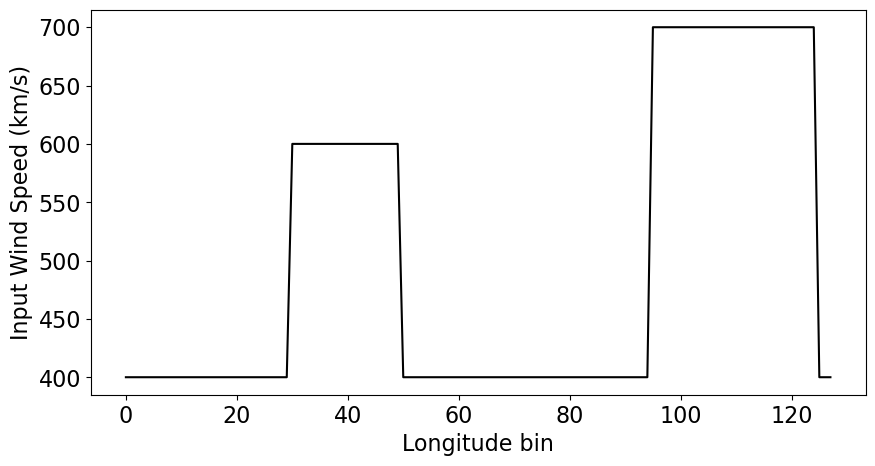

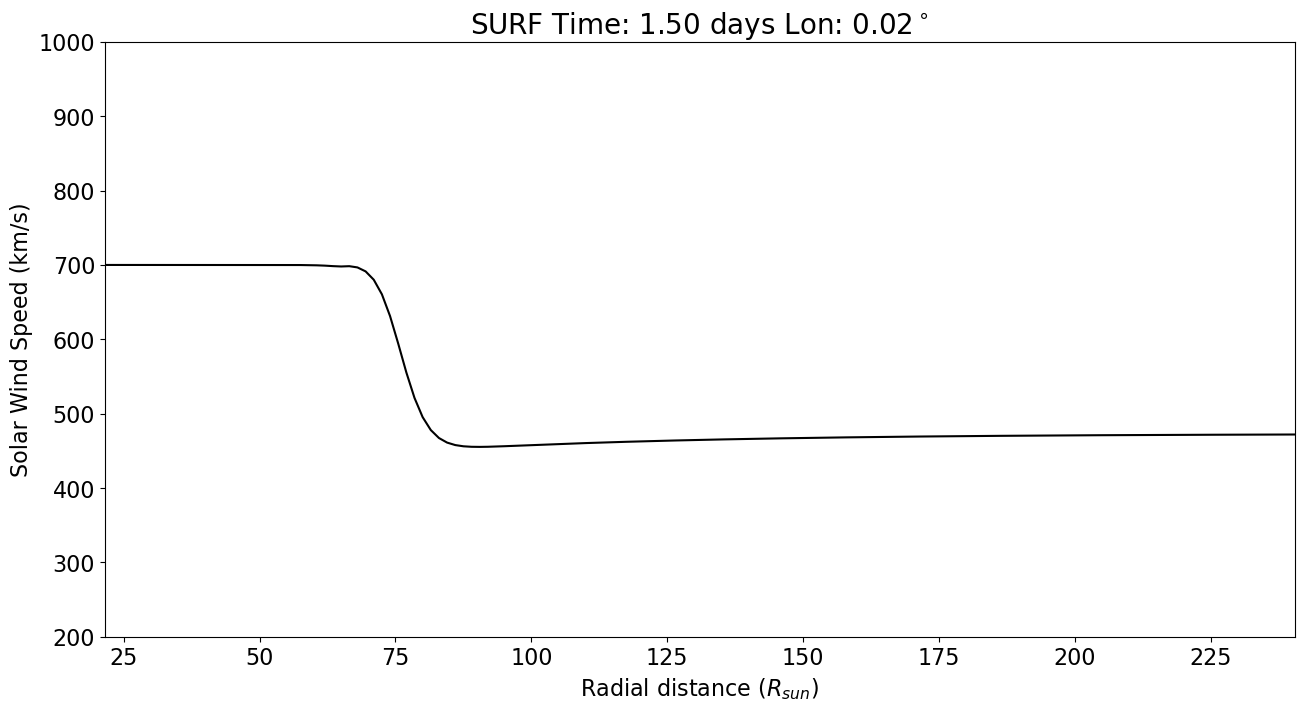

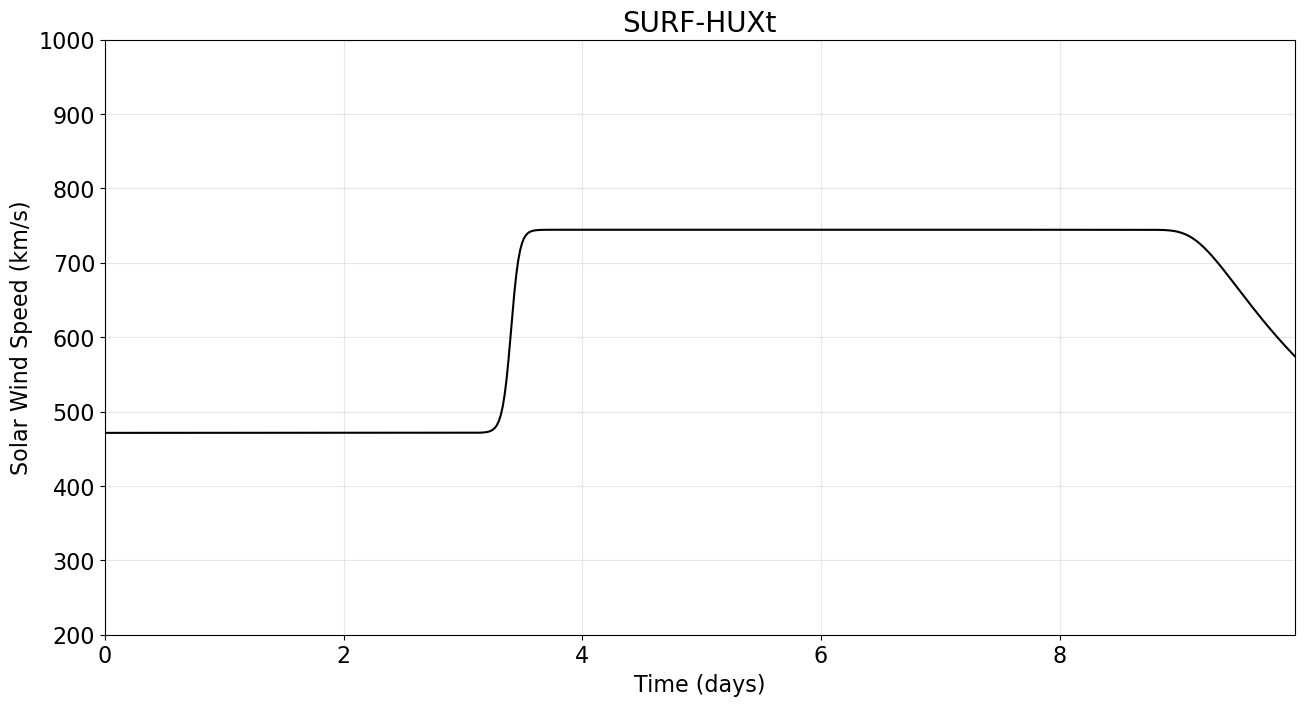

In [3]:
# Form longitudinal boundary conditions - background wind of 400 km/s with two fast streams.
v_boundary = np.ones(128) * 400 * (u.km/u.s)
v_boundary[30:50] = 600 * (u.km/u.s)
v_boundary[95:125] = 700 * (u.km/u.s)

# This boundary condition looks like
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(v_boundary,'k-')
ax.set_xlabel('Longitude bin')
ax.set_ylabel('Input Wind Speed (km/s)')

# Setup SURF to do a 5-day simulation, with model output every 4 timesteps (roughly half and hour time step), looking at 0 longitude
model = surf.SURF(v_boundary=v_boundary, lon_out=0.0*u.deg, simtime=10*u.day, dt_scale=4)

# Solve these conditions, with no ConeCMEs added.
cme_list = []
model.solve(cme_list)

# Plot the radial profile of the ambient wind profile at a fixed time (in days). 
t = 1.5*u.day
surfA.plot_radial(model, t, lon=0.0)

# Plot the time series of the ambient wind profile at a fixed radius. 
r = 1.0*u.AU
surfA.plot_timeseries(model, r, lon=0.0)

## Example 2.
<a id="example_2"></a>
Run SURF in 1D (along one longitude) with user specified V boundary conditions and a cone CME.

No initiation time specified. Defaulting to start of CR2000, 20/2/2003


(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'SURF-HUXt'}, xlabel='Time (days)', ylabel='Solar Wind Speed (km/s)'>)

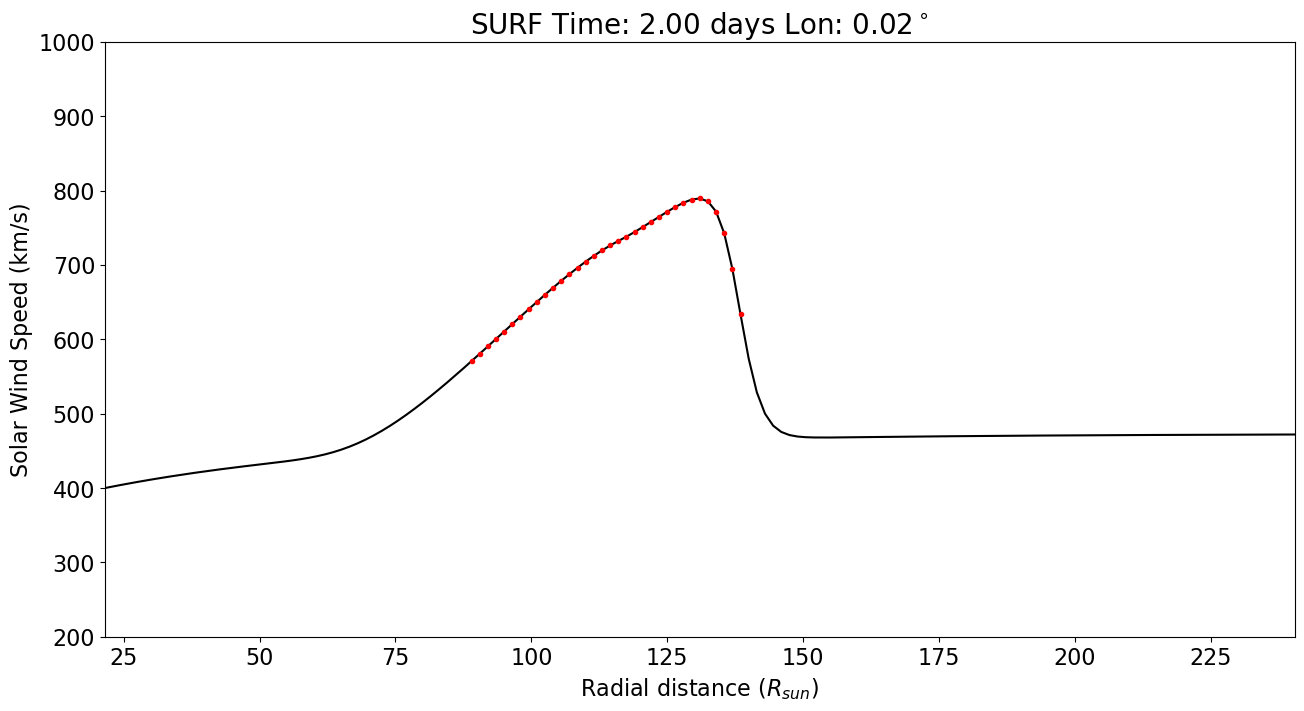

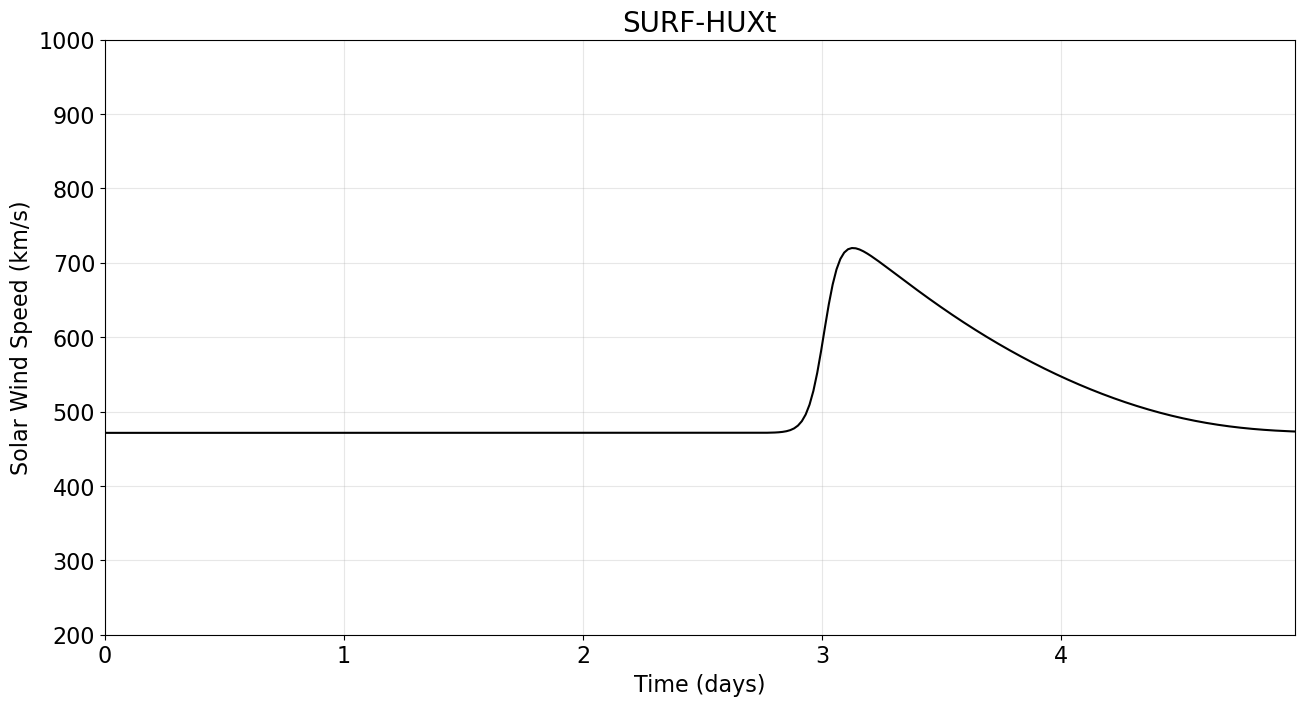

In [4]:
# Set up a ConeCME that launches half a day after the simulation begins, at 0 longitude, 30 degree width, speed 850km/s and thickness=5 solar radii
cme = surf.ConeCME(t_launch=0.5*u.day, longitude=0.0*u.deg, width=30*u.deg, v=850*(u.km/u.s), thickness=5*u.solRad)
cme_list = [cme]

# Setup SURF to do a 5-day simulation, with model output every 4 timesteps (roughly half and hour time step), looking at 0 longitude
# Form longitudinal boundary conditions - background wind of 400 km/s with two fast streams.
v_boundary = np.ones(128) * 400 * (u.km/u.s)
model = surf.SURF(v_boundary=v_boundary, lon_out=0.0*u.deg, simtime=5*u.day, dt_scale=4)

# Run the model, and this time save the results to file.
model.solve(cme_list, save=True, tag='1d_conecme_test')

# Plot the radial profile and time series of both the ambient and ConeCME solutions at a fixed time (in days). 
# Save both to file as well. These are saved in SURF>figures>SURF1D
t = 2*u.day
surfA.plot_radial(model, t, lon=0.0*u.deg, save=True)

r = 1.0*u.AU
surfA.plot_timeseries(model, r, lon=0.0*u.deg, tag='1d_cone_test_radial')

## Example 3.
<a id="example_3"></a>
SURF can also be run over multiple longitudes to provide a 2D solution. 

Here SURF is run over all longitudes, with user specified boundary conditions and a single CME

No initiation time specified. Defaulting to start of CR2000, 20/2/2003


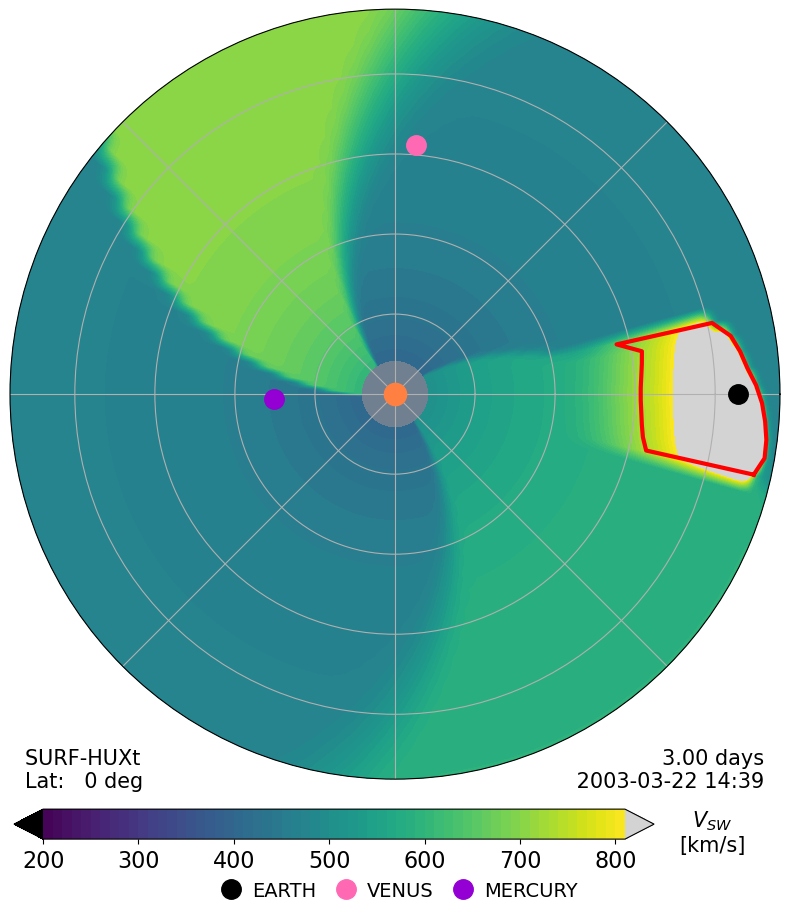

In [5]:
# Form boundary conditions - background wind of 400 km/s with two fast streams.
v_boundary = np.ones(128) * 400 * (u.km/u.s)
v_boundary[30:50] = 600 * (u.km/u.s)
v_boundary[95:125] = 500 * (u.km/u.s)

# Add a CME
cme = surf.ConeCME(t_launch=1*u.day, longitude=360*u.deg, latitude = 0*u.deg, width=30*u.deg, v=1500*(u.km/u.s), thickness=5*u.solRad)
cme_list = [cme]

# Setup SURF to do a 5-day simulation, with model output every 4 timesteps (roughly half and hour time step)
model = surf.SURF(v_boundary=v_boundary, latitude = 0*u.deg, simtime=6*u.day, dt_scale=4)

model.solve(cme_list, tag='cone_cme_test')

# Plot this out
t_interest = 3*u.day
fig, ax = surfA.plot(model, t_interest)

## Example 4.
<a id="example_4"></a>

SURF can be run with solar wind speed output from any coronal model or near-Sun observations. For convenience, there are functions for obtaining on demand boundary conditions from the Predictive Science Inc. MHDweb archive of MAS and HelioMAS runs (https://www.predsci.com/mhdweb/home.php).

HDF5 files already exist for CR2260


Text(0.5, 0.98, 'MAS/SURF')

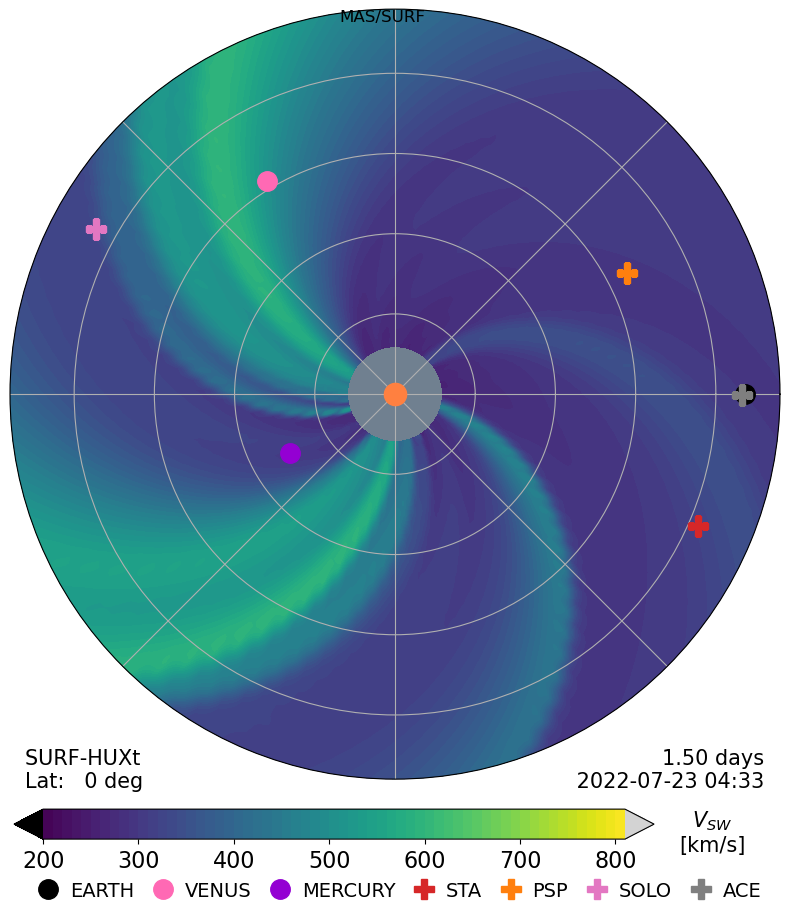

In [6]:
# SURF can be easily initiated MAS, by specifying a carrington rotation number. Data are downloaded from the Pred Sci Inc archive on demand
cr = 2260
v_mas = surfIN.get_MAS_long_profile(cr, 0.0*u.deg)

# MAS solutions are at 30 rS
model = surf.SURF(v_boundary=v_mas, cr_num=cr, simtime=5*u.day, r_min=30*u.solRad, dt_scale=4)
model.solve([])

# Plot the solution 
fig, ax = surfA.plot(model, 1.5*u.day)
fig.suptitle('MAS/SURF')

Example PFSS, WSA, DUMFRIC and CorTom output is provided in data/example_input. Data readers as provided as part of surf_inputs. 

[-1.57079641 -1.55911763 -1.54743885 -1.53576006 -1.52408128 -1.5124025
 -1.50072371 -1.48904493 -1.47736615 -1.46568736 -1.45400858 -1.4423298
 -1.43065101 -1.41897223 -1.40729345 -1.39561466 -1.38393588 -1.3722571
 -1.36057831 -1.34889953 -1.33722075 -1.32554196 -1.31386318 -1.3021844
 -1.29050561 -1.27882683 -1.26714805 -1.25546926 -1.24379048 -1.23211169
 -1.22043291 -1.20875413 -1.19707534 -1.18539656 -1.17371778 -1.16203899
 -1.15036021 -1.13868143 -1.12700264 -1.11532386 -1.10364508 -1.09196629
 -1.08028751 -1.06860873 -1.05692994 -1.04525116 -1.03357238 -1.02189359
 -1.01021481 -0.99853603 -0.98685724 -0.97517846 -0.96349968 -0.95182089
 -0.94014211 -0.92846333 -0.91678454 -0.90510576 -0.89342698 -0.88174819
 -0.87006941 -0.85839063 -0.84671184 -0.83503306 -0.82335428 -0.81167549
 -0.79999671 -0.78831792 -0.77663914 -0.76496036 -0.75328157 -0.74160279
 -0.72992401 -0.71824522 -0.70656644 -0.69488766 -0.68320887 -0.67153009
 -0.65985131 -0.64817252 -0.63649374 -0.62481496 -0.613

Text(0.5, 0.98, 'CorTom/SURF')

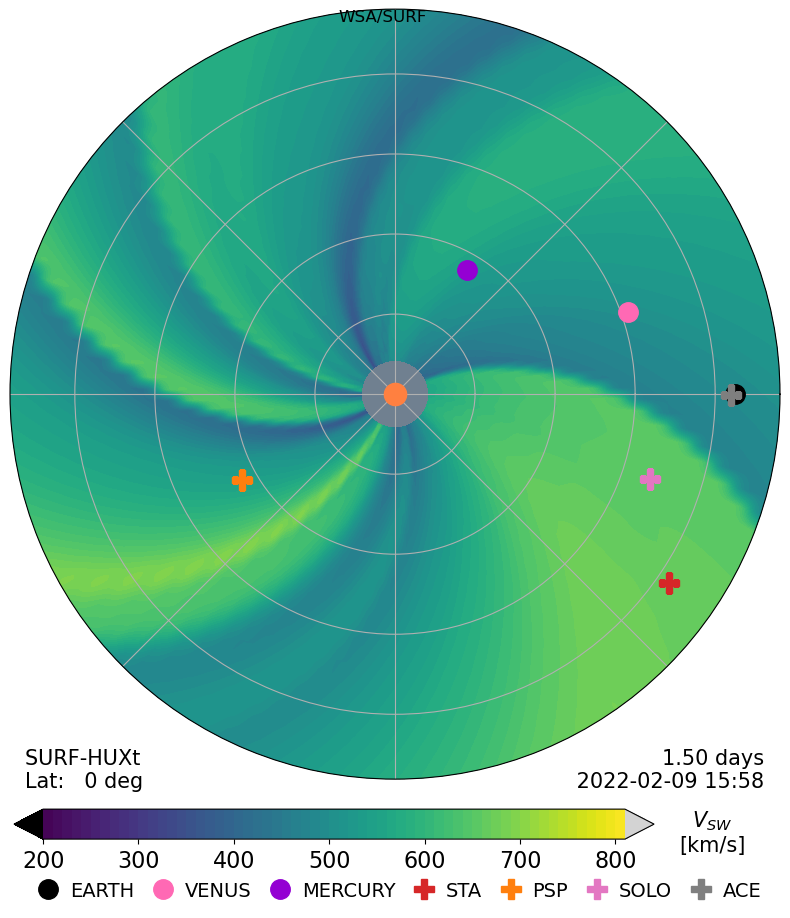

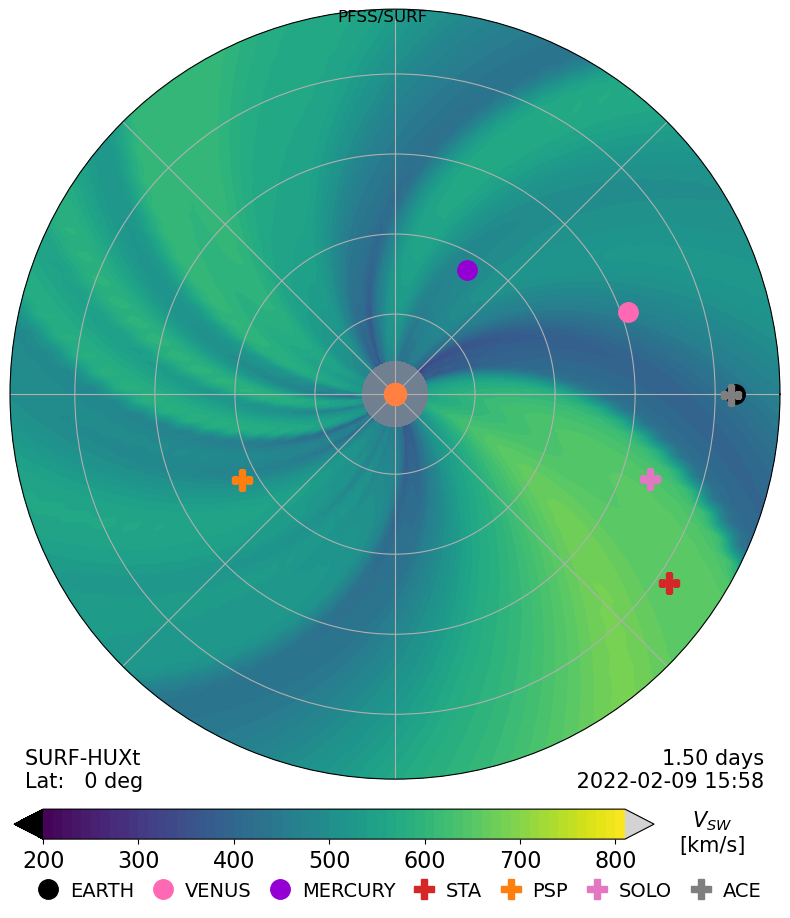

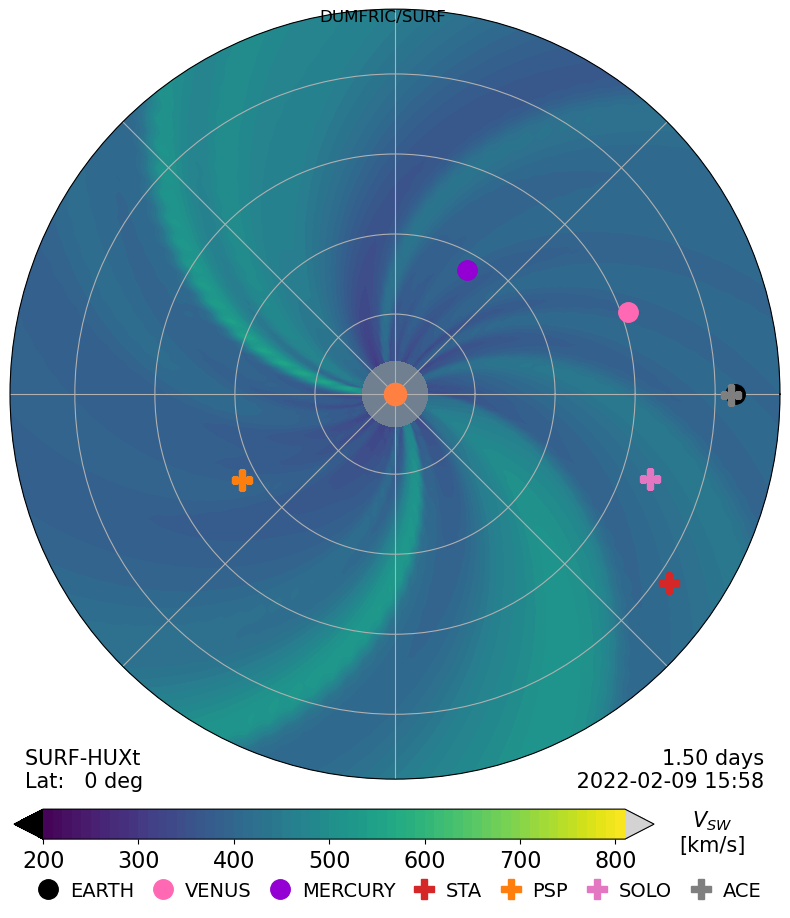

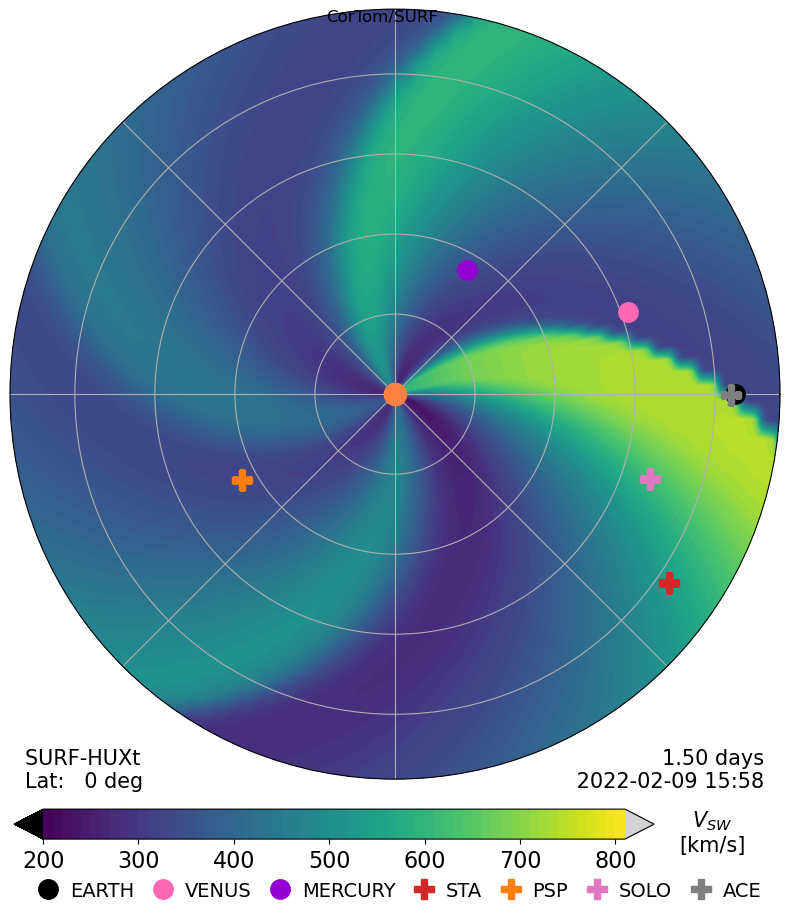

In [7]:
# Read in the data
cr = 2254

demo_dir = surf._setup_dirs_()['example_inputs']

wsafilepath = os.path.join(demo_dir, '2022-02-24T22Z.wsa.gong.fits')
pfssfilepath = os.path.join(demo_dir, 'windbound_b_pfss20220224.22.nc')
cortomfilepath = os.path.join(demo_dir, 'tomo_sta_cor2_20240224153428_8-0.dat')
dumfricfilepath = os.path.join(demo_dir, 'windbound_b20220224.12.nc')

v_wsa = surfIN.get_WSA_long_profile(wsafilepath, lat=0.0 * u.deg)
v_pfss = surfIN.get_PFSS_long_profile(pfssfilepath, lat=0.0 * u.deg)
v_dumfric = surfIN.get_PFSS_long_profile(dumfricfilepath, lat=0.0 * u.deg) #DUMFRIC uses the PFSS reader too
v_cortom = surfIN.get_CorTom_long_profile(cortomfilepath, lat=0.0 * u.deg)

# set up and run the models. WSA and PFSS maps are at 21.5 rS, CorTom at 8 rS
model = surf.SURF(v_boundary=v_wsa, cr_num=cr, simtime=5*u.day, dt_scale=4, r_min=21.5*u.solRad)
model.solve([])
fig, ax = surfA.plot(model, 1.5*u.day)
fig.suptitle('WSA/SURF')

model = surf.SURF(v_boundary=v_pfss, cr_num=cr, simtime=5*u.day, dt_scale=4, r_min=21.5*u.solRad)
model.solve([])
fig, ax = surfA.plot(model, 1.5*u.day)
fig.suptitle('PFSS/SURF')

model = surf.SURF(v_boundary=v_dumfric, cr_num=cr, simtime=27*u.day, dt_scale=4, r_min=21.5*u.solRad)
model.solve([])
fig, ax = surfA.plot(model, 1.5*u.day)
fig.suptitle('DUMFRIC/SURF')

model = surf.SURF(v_boundary=v_cortom, cr_num=cr, simtime=27*u.day, dt_scale=4, r_min=8*u.solRad)
model.solve([])
fig, ax = surfA.plot(model, 1.5*u.day)
fig.suptitle('CorTom/SURF')


surf_inputs also has a function to create coneCME objects from the cone2bc.in files that are used to drive Enlil. 

{'hit': True, 'hit_id': 439, 't_arrive': <Time object: scale='utc' format='jd' value=2460441.569158704>, 't_transit': <Quantity 1.98024241 d>, 'lon': <Quantity 6.28318529 rad>, 'r': <Quantity 217.18348521 solRad>, 'v': <Quantity 634.69443185 km / s>}


Text(0.5, 0.98, 'WSA/SURF')

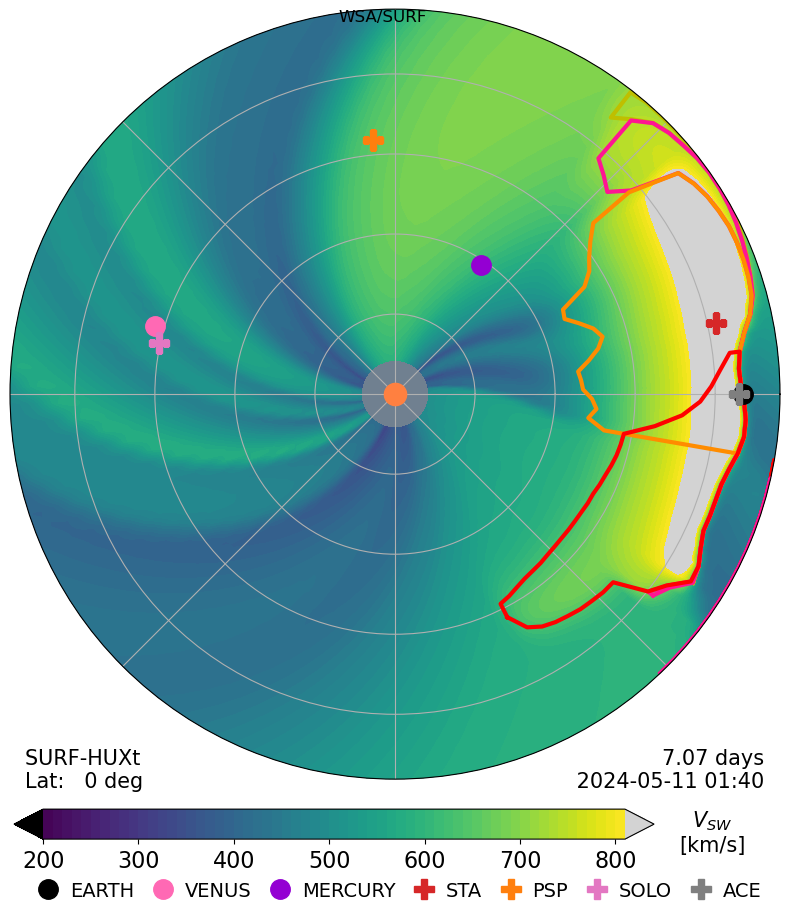

In [8]:
demo_dir = surf._setup_dirs_()['example_inputs']

wsafilepath = os.path.join(demo_dir, 'wsa_gong_2024050906.fits')
v_wsa = surfIN.get_WSA_long_profile(wsafilepath, lat=0.0 * u.deg)

time = datetime.datetime(2024, 5, 4, 0)
cr, cr_lon_init = surfIN.datetime2surfinputs(time)

model = surf.SURF(v_boundary=v_wsa, cr_num=cr, cr_lon_init=cr_lon_init, simtime=12*u.day, dt_scale=4, r_min=21.5*u.solRad)

conefilepath = os.path.join(demo_dir, 'cone_cme_2024050906.in')
cme_list = surfIN.ConeFile_to_ConeCME_list(model, conefilepath)


model.solve(cme_list)

# Model solve makes a deep copy of the cme list and stores them as an attribute model.cmes
# The individual ConeCME attributes in the model.cmes list get updated by model.solve
# So to analyse CMEs you should refer to model.cmes after model solve. 

cme = model.cmes[-1]
arrival_stats = cme.compute_arrival_at_body('EARTH')
print(arrival_stats)

t_plot = model.time_out[arrival_stats["hit_id"]]
    
fig, ax = surfA.plot(model, t_plot)
fig.suptitle('WSA/SURF')

## Example 5.
<a id="example_5"></a>
There is also a function to animate SURF output. Movies are saved in SURF>Figures as .mpg4

No initiation time specified. Defaulting to start of CR2000, 20/2/2003


2026-03-24 13:24:56 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2026-03-24 13:24:56 - matplotlib.animation - INFO: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1000x1000 -pix_fmt rgba -framerate 20.0 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y 'C:\Users\vy902033\AppData\Local\surf\figures\SURF_CR2000_cone_cme_test_movie.mp4'


Rendering 200 frames. Expected time: 40 secs
mp4 file written to C:\Users\vy902033\AppData\Local\surf\figures\SURF_CR2000_cone_cme_test_movie.mp4


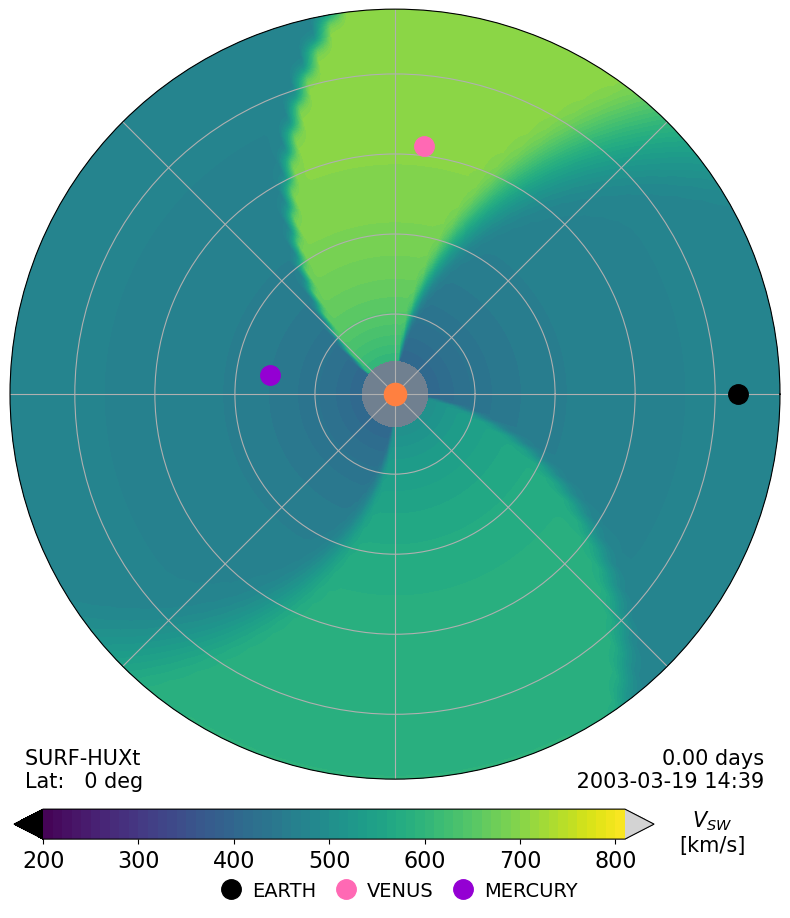

In [9]:
# Set up and run previous example of idealised solar wind with single CME
v_boundary = np.ones(128) * 400 * (u.km/u.s)
v_boundary[30:50] = 600 * (u.km/u.s)
v_boundary[95:125] = 500 * (u.km/u.s)

# Add a CME
cme = surf.ConeCME(t_launch=1*u.day, longitude=360*u.deg, latitude=0*u.deg, width=30*u.deg, v=1000*(u.km/u.s), thickness=5*u.solRad)

# Setup SURF to do a 5-day simulation, with model output every 4 timesteps (roughly half and hour time step)
model = surf.SURF(v_boundary=v_boundary, latitude=0*u.deg, simtime=6*u.day, dt_scale=4)
model.solve([cme], tag='cone_cme_test')

# Create the animation
#==========================
surfA.animate(model, tag='cone_cme_test') # This takes about two minutes.

## Example 6.
<a id="example_6"></a>
SURF results can be saved to a HDF5 file, either automatically in the solve method, or by a separate save method. There is also a load function. 

No initiation time specified. Defaulting to start of CR2000, 20/2/2003


(<Figure size 1000x1000 with 2 Axes>, <PolarAxes: >)

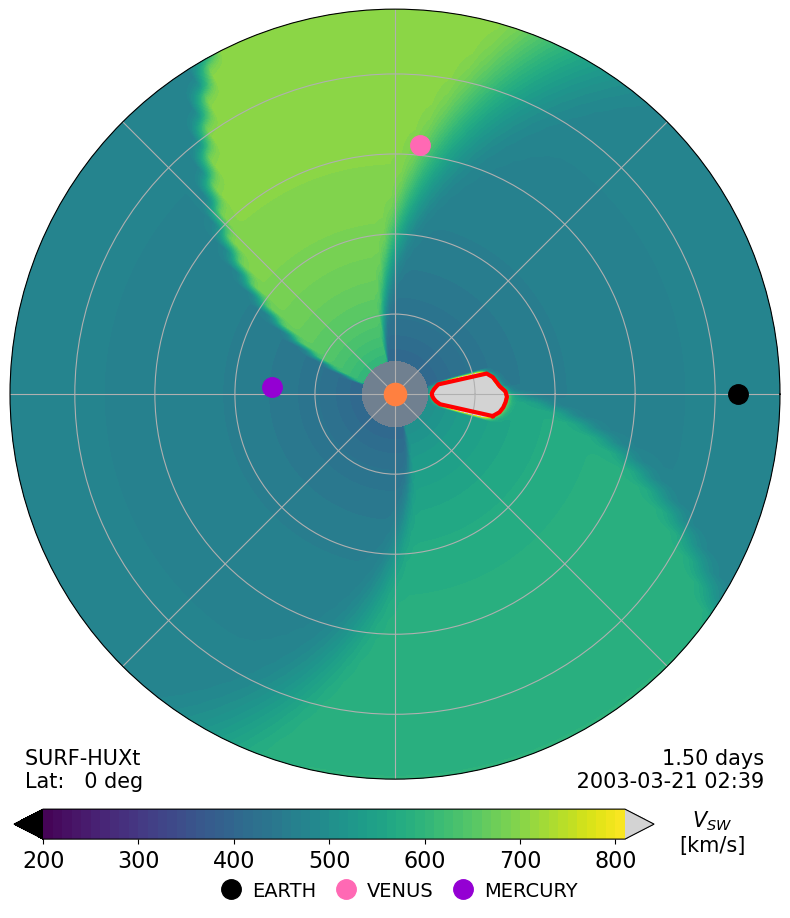

In [10]:
# Set up and run previous example of idealised solar wind with single CME
v_boundary = np.ones(128) * 400 * (u.km/u.s)
v_boundary[30:50] = 600 * (u.km/u.s)
v_boundary[95:125] = 500 * (u.km/u.s)

# Add a CME
cme = surf.ConeCME(t_launch=1*u.day, longitude=360*u.deg, latitude=0*u.deg, width=30*u.deg, v=1000*(u.km/u.s), thickness=5*u.solRad)

# Setup SURF to do a 5-day simulation, with model output every 4 timesteps (roughly half and hour time step)
model = surf.SURF(v_boundary=v_boundary, latitude=0*u.deg, simtime=6*u.day, dt_scale=4)
model.solve([cme], tag='cone_cme_test')

# Save the data
out_path = model.save(tag='cone_cme_test')

# And load it back in with
model2, cme_list2 = surf.load_SURF_run(out_path)

#plot it
surfA.plot(model2, 1.5*u.day)

## Example 7.
<a id="example_7"></a>
CMEs are tracked through the SURF domain using test particles that advect with the flow. These coordinates are accessible via the ConeCME objects.

No initiation time specified. Defaulting to start of CR2000, 20/2/2003
[61.00424366 65.27800234 67.61001846 69.05623113 69.93153316 69.01103484
 65.47431409 63.21489752 61.09807635 57.22588839 27.0204442  25.48989838
 24.27106557 23.53662524 23.03250311 23.03250311 23.53662524 24.27106557
 25.5332572  28.2021157 ] solRad


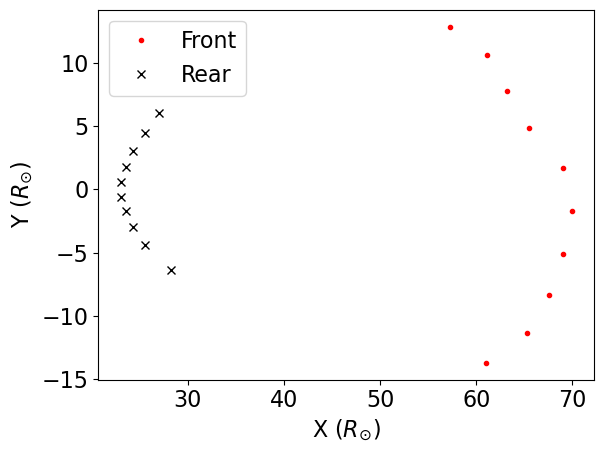

In [11]:
# Set up and run previous example of idealised solar wind with single CME
v_boundary = np.ones(128) * 400 * (u.km/u.s)
v_boundary[30:50] = 600 * (u.km/u.s)
v_boundary[95:125] = 500 * (u.km/u.s)

# Add a CME
cme = surf.ConeCME(t_launch=1*u.day, longitude=360*u.deg, latitude=0*u.deg, width=30*u.deg, v=1000*(u.km/u.s), thickness=5*u.solRad)

# Setup SURF to do a 5-day simulation, with model output every 4 timesteps (roughly half and hour time step)
model = surf.SURF(v_boundary=v_boundary, latitude=0*u.deg, simtime=5*u.day, dt_scale=4)
model.solve([cme], tag='cone_cme_test')

# Extract the CME position and convert to cartesian for plotting
cme = model.cmes[0]
id_t = np.argmin(np.abs(model.time_out - 1.5*u.d))
r = cme.coords[id_t]['r'].to(u.solRad)
lon = cme.coords[id_t]['lon']
x = r * np.cos(lon)
y = r * np.sin(lon)

print(x)

# There is also a "front_id" field to separate the nose and rear.
id_front = cme.coords[id_t]['front_id'] == 1.0
id_back = cme.coords[id_t]['front_id'] == 0.0

# Plot it
fig, ax = plt.subplots() # Compare this with the boundary in the frame above.
ax.plot(x[id_front] , y[id_front] , 'r.', label='Front')
ax.plot(x[id_back] , y[id_back] , 'kx', label='Rear')
ax.set_xlabel('X ($R_{\\odot}$)')
ax.set_ylabel('Y ($R_{\\odot}$)')
ax.legend()

The flow speed is also tracked by the CME particles, and is also accessible as a CME coordinate as follows.

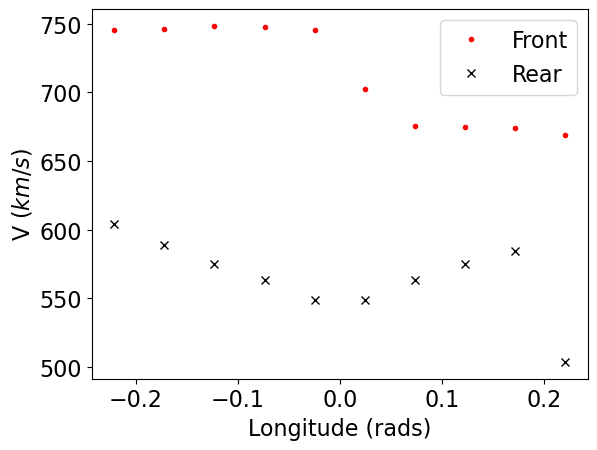

In [12]:
# Look at the same CME at the same time as before. 
cme = model.cmes[0]
id_t = np.argmin(np.abs(model.time_out - 1.5*u.d))
v = cme.coords[id_t]['v']
lon = cme.coords[id_t]['lon']

# There is also a "front_id" field to separate the nose and rear.
id_front = cme.coords[id_t]['front_id'] == 1.0
id_back = cme.coords[id_t]['front_id'] == 0.0

# Plot it out
fig, ax = plt.subplots()
ax.plot(lon[id_front] , v[id_front] , 'r.', label='Front')
ax.plot(lon[id_back] , v[id_back] , 'kx', label='Rear')
ax.set_xlabel('Longitude (rads)')
ax.set_ylabel('V ($km/s$)')
ax.legend()

## Example 8.
<a id="example_8"></a>
Multiple Cone CMEs can be inserted into SURF in any run. Also, functions are provided to download inner boundary conditions from the HelioMAS model. Below we set up SURF to run for Carrington rotation 2100, retrieving the boundary condition from Predictive Science (unless it is already downloaded). Then three Cone CMEs are inserted, and the output plotted.

HDF5 files already exist for CR2101


(<Figure size 1000x1000 with 2 Axes>, <PolarAxes: >)

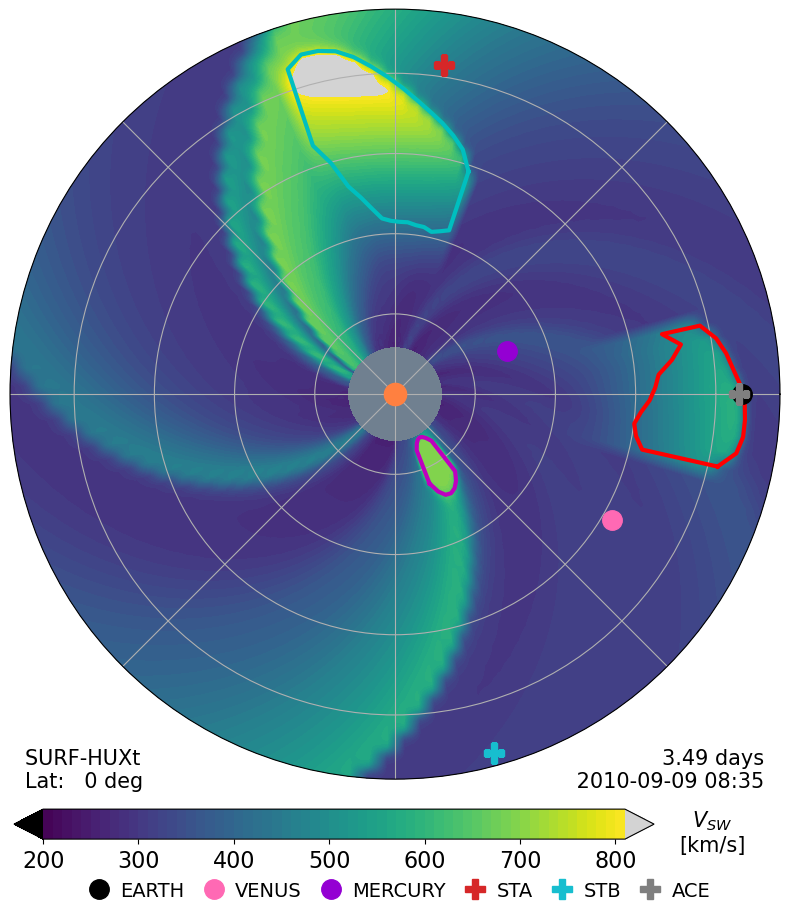

In [13]:
# Get inner boundary condition from Carrington rotation 2100
cr=2101
vr_in = surfIN.get_MAS_long_profile(cr, 0.0*u.deg)
# Setup SURF to do a 5-day simulation, with model output every 4 timesteps (roughly half and hour time step).
model = surf.SURF(v_boundary=vr_in, cr_num=cr, r_min=30*u.solRad,simtime=5*u.day, dt_scale=4)

# Produce a list of ConeCMEs to pass to SURF
daysec = 86400
times = [0.5*daysec, 1.5*daysec, 3*daysec]
speeds = [850, 1000, 700]
lons = [0, 90, 300]
widths = [30, 40, 20]
thickness = [5, 4, 2]
cme_list = []
for t, l, w, v, thick in zip(times, lons, widths, speeds, thickness):
    cme = surf.ConeCME(t_launch=t*u.s, longitude=l*u.deg, width=w*u.deg, v=v*model.kms, initial_height = 30*u.solRad,thickness=thick*u.solRad)
    cme_list.append(cme)

model.solve(cme_list, save=True, tag='multi_cones') 
surfA.plot(model, 3.5*u.day)

## Example 9.
<a id="example_9"></a>
There is also an ephemeris of the HEEQ, HAE, and Carrington coordiates of Earth, Mercury, Venus, STEREO-A and STEREO-B

HDF5 files already exist for CR2100


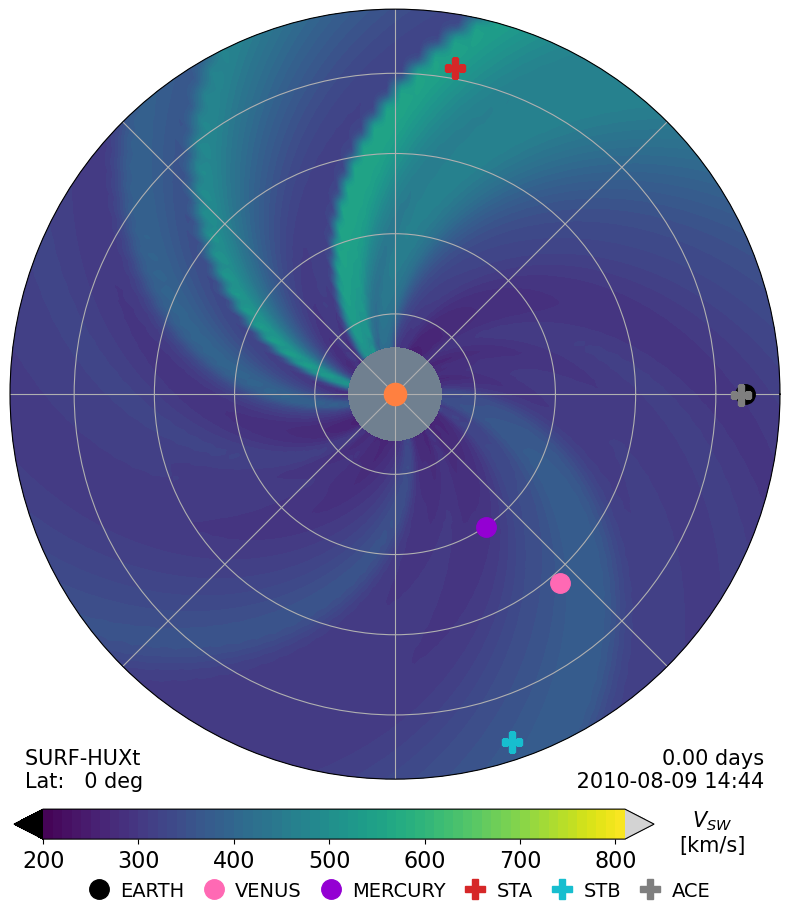

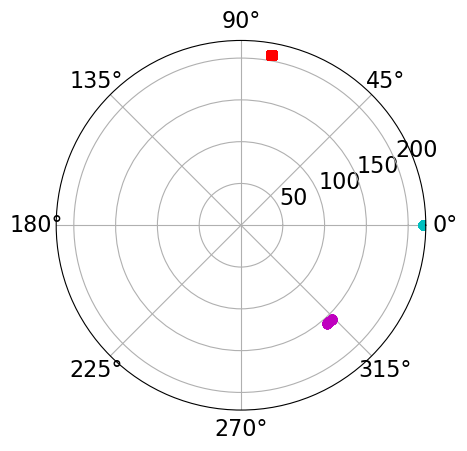

In [14]:
cr=2100
vr_in = surfIN.get_MAS_long_profile(cr, 0.0*u.deg)
model = surf.SURF(v_boundary=vr_in, cr_num=cr, r_min=30*u.solRad, simtime=5*u.day, dt_scale=4)
model.solve([])

# These are automatically plotted on model solutions derived from a particular Carrington rotation.
surfA.plot(model, model.time_out[0])

# You can retrieve a bodies position at each model timestep like:
earth = model.get_observer('earth')
sta = model.get_observer('sta')
venus = model.get_observer('venus')

# The bodies HEEQ and Carrington coordinates are attributes.
# So to plot them:
fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
ax.plot(earth.lon, earth.r, 'co')
ax.plot(sta.lon, sta.r, 'rs')
ax.plot(venus.lon, venus.r, 'mo')

## Example 10.
<a id="example_10"></a>
SURF can also be run over a limited range of longitudes. As SURF is a purely radial model, it can be run over any set of longitudes. This could save disk-space and runtime if you are interested in large ensembles. This is done with the `lon_start` and `lon_stop` arguments.


HDF5 files already exist for CR2120


(<Figure size 1000x1000 with 2 Axes>, <PolarAxes: >)

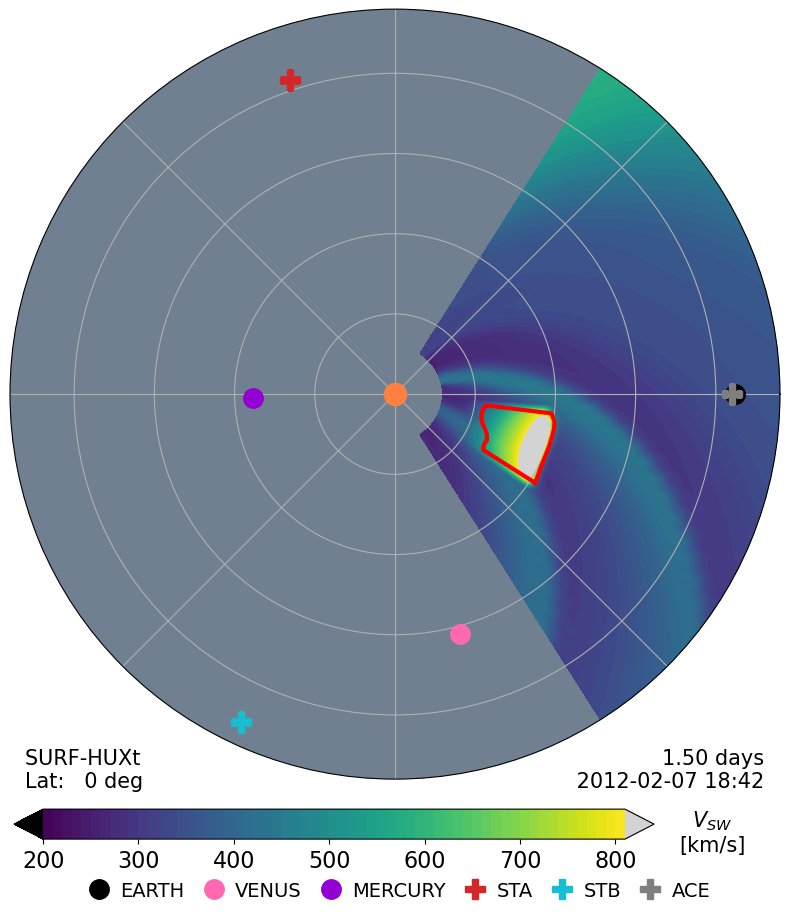

In [15]:
# Set up SURF over a limited longitude range.
cr=2120
vr_in = surfIN.get_MAS_long_profile(cr, 0.0*u.deg)
model = surf.SURF(v_boundary=vr_in, cr_num=cr, lon_start=300*u.deg, lon_stop=60*u.deg, r_min=30*u.solRad, simtime=5*u.day, dt_scale=4)

# Get a list of two ConeCMEs
daysec = 86400
times = [0.5*daysec, 2*daysec]
speeds = [1000, 850]
lons = [-20, 20]
widths = [30, 30]
thickness = [8, 4]
cme_list = []
for t, l, w, v, thick in zip(times, lons, widths, speeds, thickness):
    cme = surf.ConeCME(t_launch=t*u.s, longitude=l*u.deg, width=w*u.deg, v=v*model.kms, initial_height = 30*u.solRad, thickness=thick*u.solRad)
    cme_list.append(cme)

model.solve(cme_list, save=True, tag='multi_cones') 

t_interest = 1.5*u.day
surfA.plot(model, t_interest)

## Example 11.
<a id="example_11"></a>
The initial carrington longitude of Earth can be specified with the `cr_lon_init` argument. This sets the `time_init` attribute, so model times can be converted to UTC.

HDF5 files already exist for CR2120
360.0 deg 2012-02-06T06:42:33.508
270.0 deg 2012-02-13T02:45:10.629
180.0 deg 2012-02-19T22:47:12.384


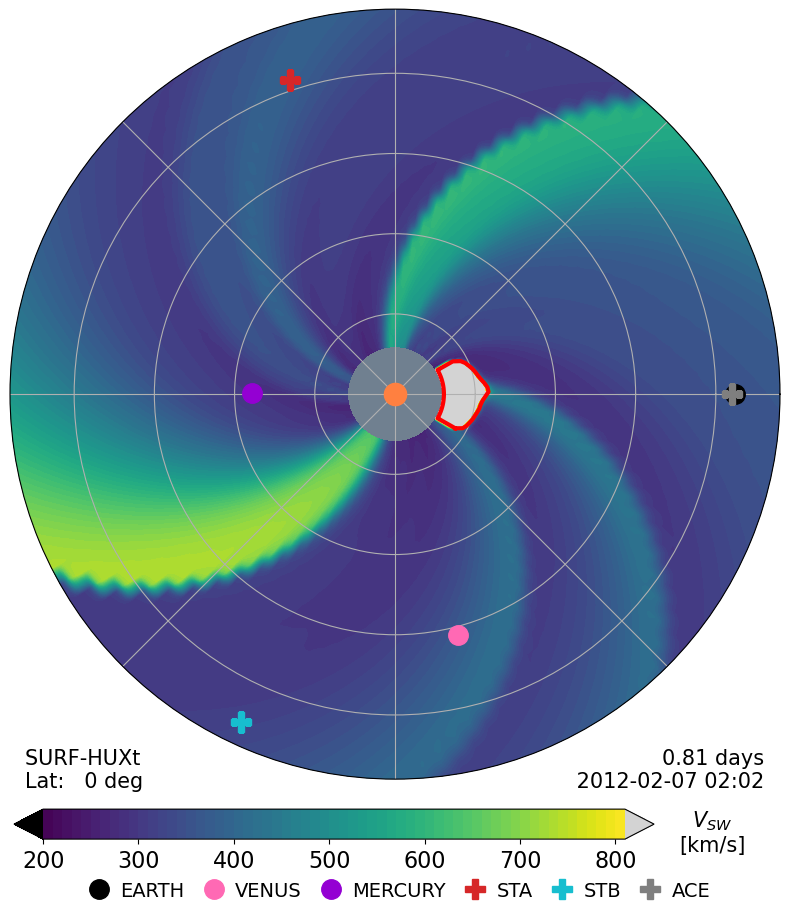

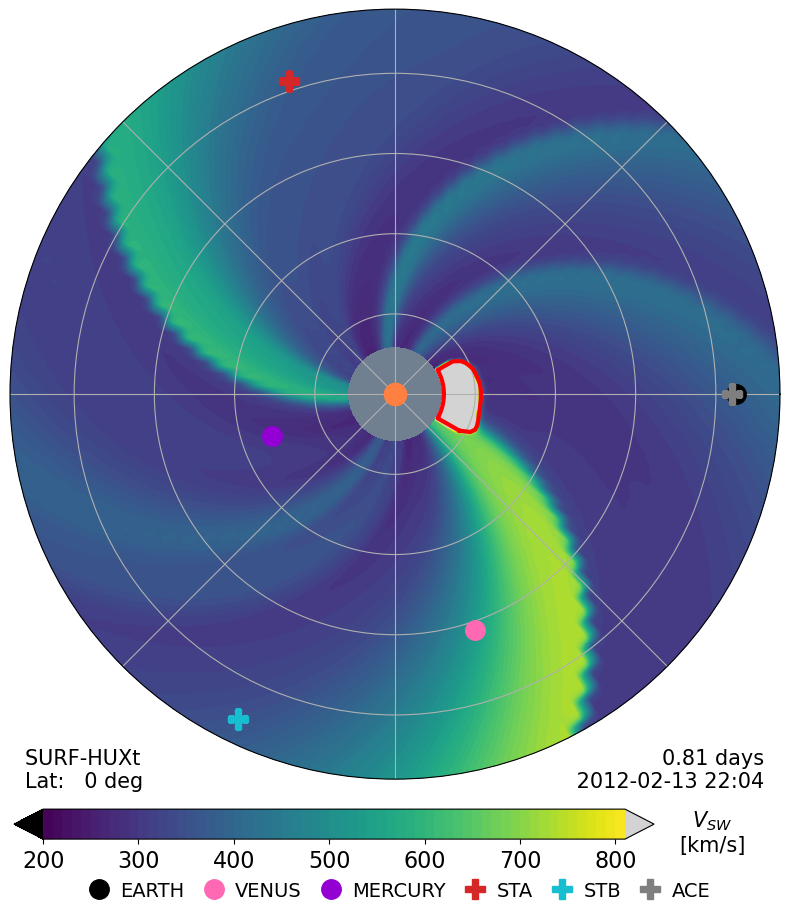

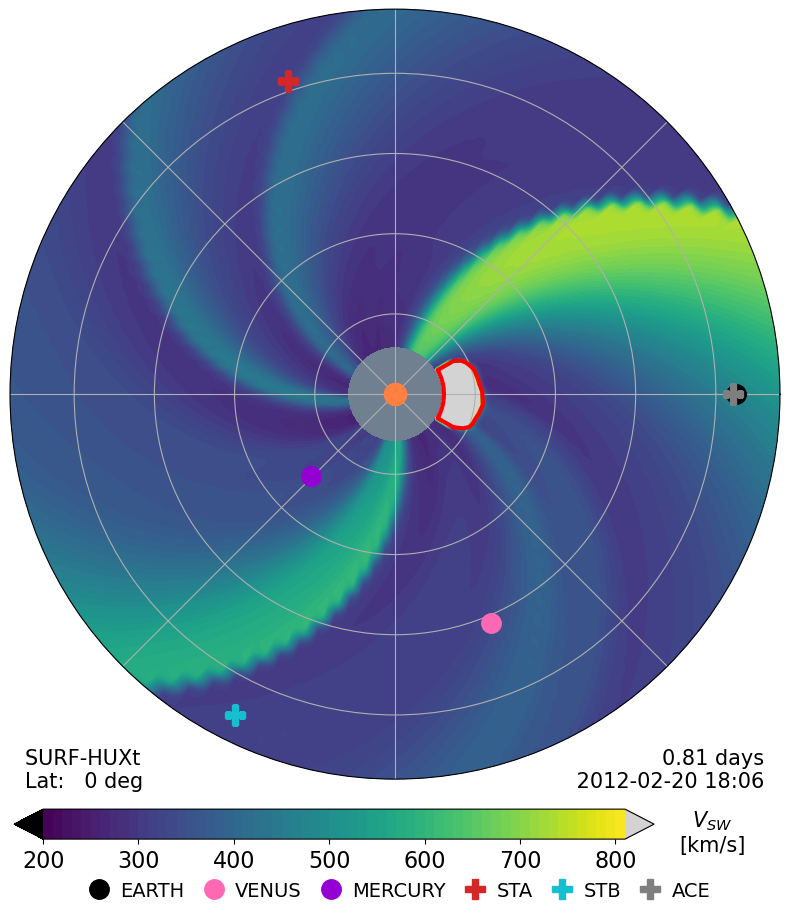

In [16]:
cr=2120
vr_in = surfIN.get_MAS_long_profile(cr, 0.0*u.deg)

for cr_lon in [360, 270, 180]:
    model = surf.SURF(v_boundary=vr_in, cr_num=cr, cr_lon_init=cr_lon*u.deg, r_min=30*u.solRad, simtime=5*u.day, dt_scale=4)
    cme = surf.ConeCME(t_launch=0.5*u.day, longitude=0.0*u.deg, width=60*u.deg, v=1000*(u.km/u.s), initial_height=30*u.solRad, thickness=5*u.solRad)
    model.solve([cme])
    cr_tag = 'cr_lon_{:03d}'.format(np.int32(cr_lon))
    surfA.plot(model, model.time_out[50], save=True, tag=cr_tag)
    print(model.cr_lon_init.to('deg'), model.time_init.isot)


## Example 12.
<a id="example_12"></a>
SURF can be run with two reference frames - the inner boundary is rotated with either the mean sidreal rotation rate, or with the synodic rotation rate from Earth's perspective. This is set with the `frame` argument. This doesn't always have a large effect on the solution, but can be worth considering. For example, in highly structured solar wind it can affect the CME arrival time by a few hours. 

HDF5 files already exist for CR2120


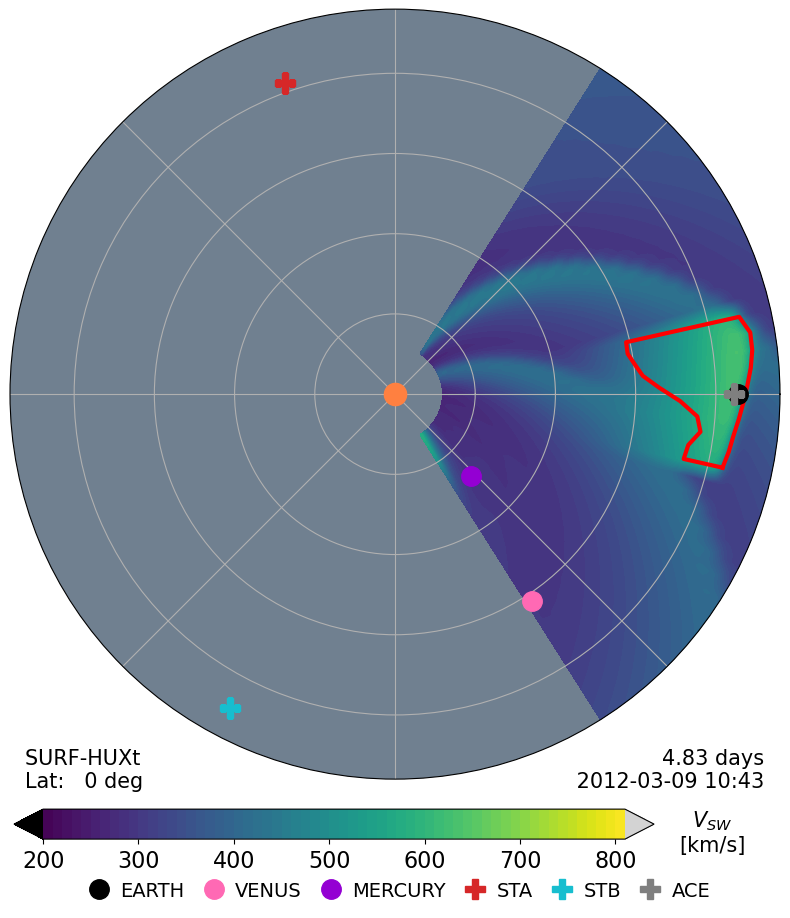

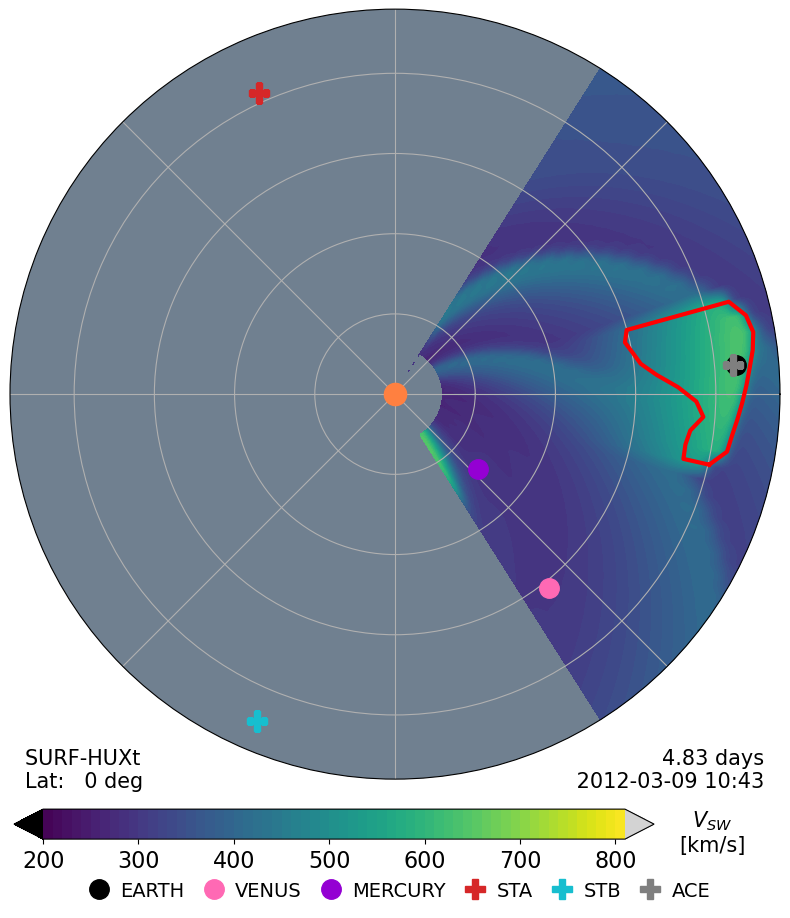

In [17]:
cr=2120
vr_in = surfIN.get_MAS_long_profile(cr, 0.0*u.deg)

# Synodic
model = surf.SURF(v_boundary=vr_in, cr_num=cr, cr_lon_init=0*u.deg, simtime=10*u.day, r_min=30*u.solRad,
                  dt_scale=4, lon_start=300*u.deg, lon_stop=60*u.deg, frame='synodic')
cme = surf.ConeCME(t_launch=2*u.day, longitude=0.0*u.deg, width=30*u.deg, v=1000*(u.km/u.s), initial_height=30*u.solRad, thickness=5*u.solRad)
model.solve([cme])
fig, ax = surfA.plot(model, model.time_out[300], save=True, tag='synodic')

# Sidereal
model = surf.SURF(v_boundary=vr_in, cr_num=cr, cr_lon_init=0*u.deg, simtime=10*u.day, r_min=30*u.solRad, 
                  dt_scale=4, lon_start=300*u.deg, lon_stop=60*u.deg, frame='sidereal')
cme = surf.ConeCME(t_launch=2*u.day, longitude=0.0*u.deg, width=30*u.deg, v=1000*(u.km/u.s), initial_height=30*u.solRad, thickness=5*u.solRad)
model.solve([cme])
fig, ax = surfA.plot(model, model.time_out[300], save=True, tag='sidereal')

## Example 13.
<a id="example_13"></a>
A function is included to compute the arrival time of CMEs at the solar system bodies available in the Observer class - Mercury, Venus, Earth, STEREO-A and STEREO-B. We will use this to show how the different synodic and sidereal frames can affect the CMEs arrival time. In this instance the CME is strongly affected by a high speed stream, and the CME arrival time at Earth is about 4 hours different for the synodic and sidereal frames. 

HDF5 files already exist for CR2056
**************************************
sidereal: Earth arrival:2007-05-27T10:29:19.220,  Transit time:1.96 d days, Arrival longitude:0.04 rad, Speed:784.08 km / s
**************************************
synodic: Earth arrival:2007-05-27T12:43:03.492,  Transit time:2.05 d days, Arrival longitude:6.28 rad, Speed:746.46 km / s


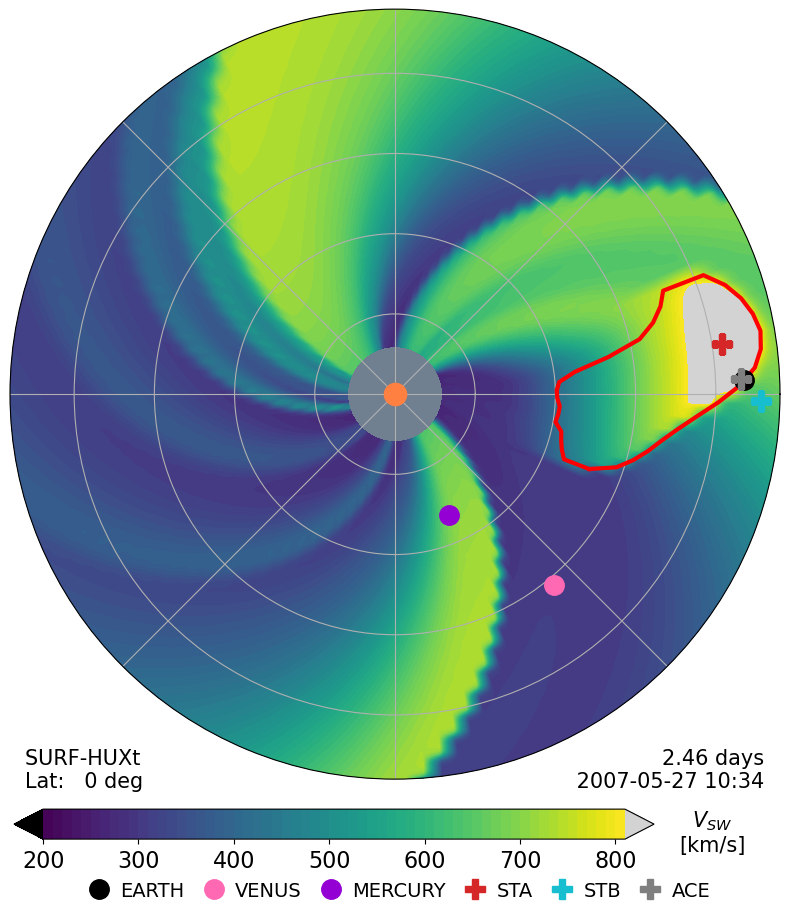

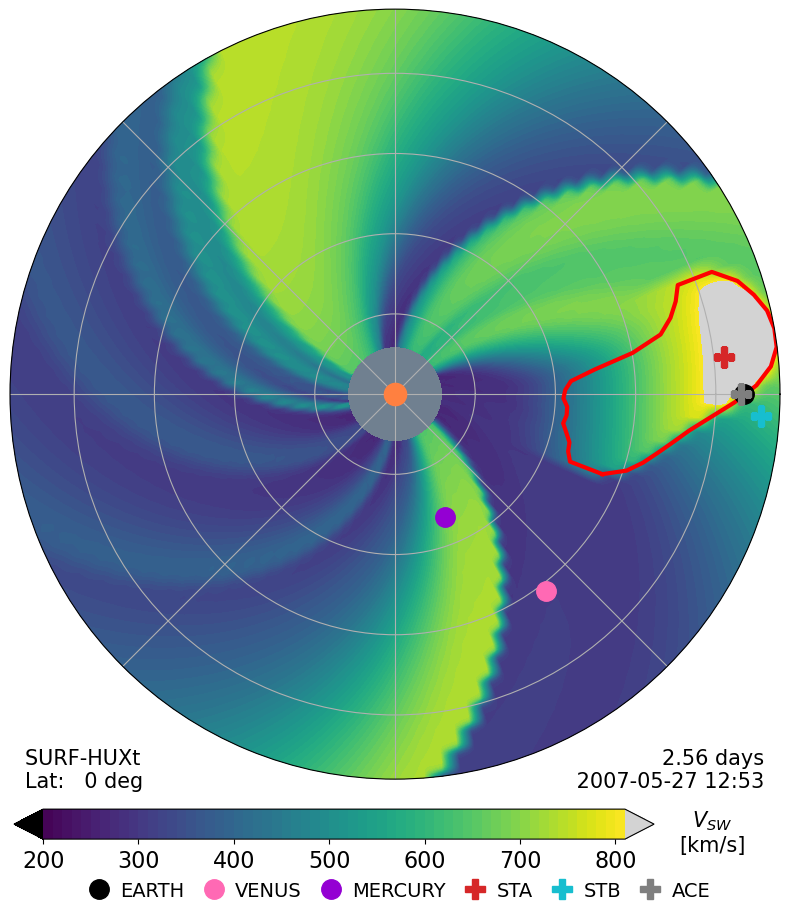

In [18]:
cr=2056
vr_in = surfIN.get_MAS_long_profile(cr, 0.0*u.deg)

for frame in ['sidereal', 'synodic']:
    model = surf.SURF(v_boundary=vr_in, cr_num=cr, cr_lon_init=0*u.deg, r_min=30*u.solRad, simtime=5*u.day, dt_scale=4, frame=frame)
    cme = surf.ConeCME(t_launch=0.5*u.day, longitude=0.0*u.deg, width=45*u.deg, initial_height=30*u.solRad, v=1000*(u.km/u.s), thickness=0*u.solRad)
    model.solve([cme])
    cme = model.cmes[0]
    stats = cme.compute_arrival_at_body('EARTH')
    
    #  Plot the solution at the nearest time step to impact.
    surfA.plot(model, model.time_out[stats['hit_id']])
    
    #  Print out some arrival stats
    print("**************************************")
    output_text = "{}: Earth arrival:{},  Transit time:{:3.2f} days, Arrival longitude:{:3.2f}, Speed:{:3.2f}" 
    print(output_text.format(frame, stats['t_arrive'].isot, stats['t_transit'], stats['lon'], stats['v']))


## Example 14.
<a id="example_14"></a>
Most of the model parameters are attributes of the SURF class and so can be accessed like:

In [19]:
cr=2120
vr_in = surfIN.get_MAS_long_profile(cr, 0.0*u.deg)
model = surf.SURF(v_boundary=vr_in, cr_num=cr, cr_lon_init=0*u.deg, simtime=5*u.day, dt_scale=4, r_min=30*u.solRad, frame='synodic')
cme = surf.ConeCME(t_launch=0.5*u.day, longitude=0.0*u.deg, width=60*u.deg, v=1000*(u.km/u.s), initial_height=30*u.solRad, thickness=5*u.solRad)
model.solve([cme])

# Model time step from the CFL condition:
print('Model time step is: ', model.dt)
# Output model time step
print('Data output time step is', model.dt_out)
# A list of all attributes is in the documentation
help(model)

HDF5 files already exist for CR2120
Model time step is:  347.85 s
Data output time step is 1391.4 s
Help on SURF in module surf object:

class SURF(builtins.object)
 |  SURF(
 |      v_boundary=<Quantity nan km / s>,
 |      b_boundary=nan,
 |      rho_boundary=nan,
 |      temp_boundary=nan,
 |      cr_num=nan,
 |      cr_lon_init=<Quantity 360. deg>,
 |      latitude=<Quantity 0. deg>,
 |      r_min=<Quantity 21.5 solRad>,
 |      r_max=<Quantity 240. solRad>,
 |      lon_out=<Quantity nan rad>,
 |      lon_start=<Quantity nan rad>,
 |      lon_stop=<Quantity nan rad>,
 |      simtime=<Quantity 5. d>,
 |      dt_scale=1.0,
 |      frame='synodic',
 |      input_v_ts=<Quantity nan km / s>,
 |      input_b_ts=nan,
 |      input_rho_ts=<Quantity nan kg / m3>,
 |      input_temp_ts=<Quantity nan K>,
 |      input_iscme_ts=nan,
 |      input_t_ts=<Quantity nan s>,
 |      track_cmes=True,
 |      accel_limit=True,
 |      solver='huxt',
 |      parallel=False
 |  )
 |
 |  A class containi

## Example 15.
<a id="example_15"></a>
The inner boundary of SURF defaults to 21.5 Rs. But it can be specified by the user. To use the HelioMAS solutions with lower inner boundary heights, a function is provided to give an approximate mapping between the 21.5 Rs solution and a lower specified height. Below, the 30Rs solution is mapped to 21.5Rs, the standard for Enlil, etc.

WARNING: It is not advisable to map solutions beyond around 5-10 rS, as the acceleration equation may not be valid. Also note that as results need to be interpolated onto a regular grid, mapped and unmapped solutions will not be identical.

HDF5 files already exist for CR2054


(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'SURF-HUXt'}, xlabel='Time (days)', ylabel='Solar Wind Speed (km/s)'>)

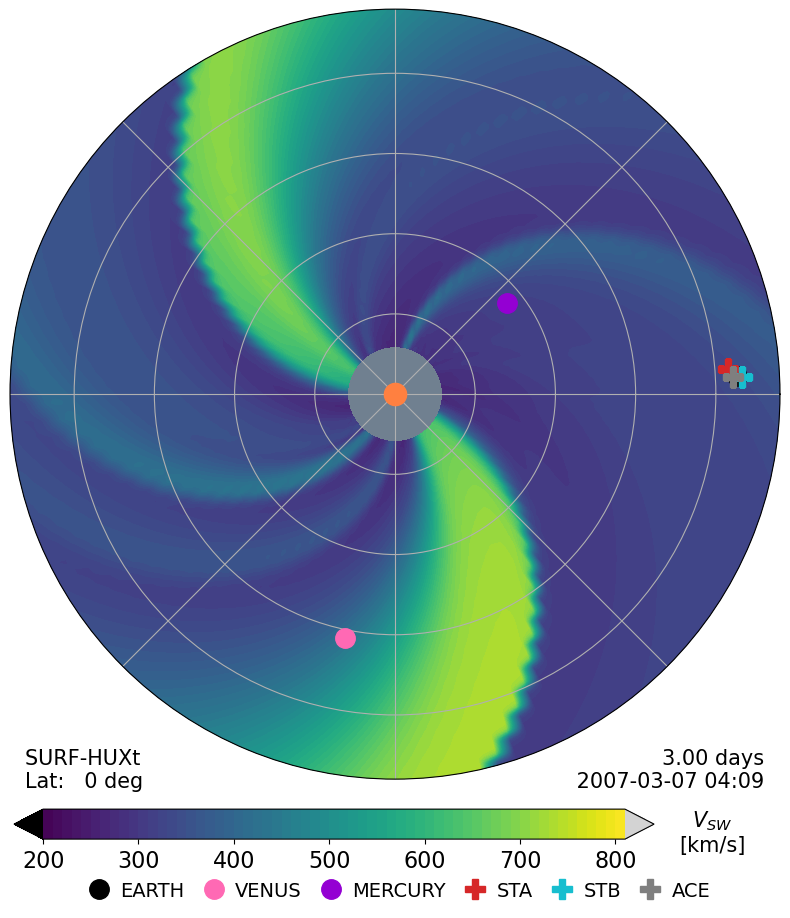

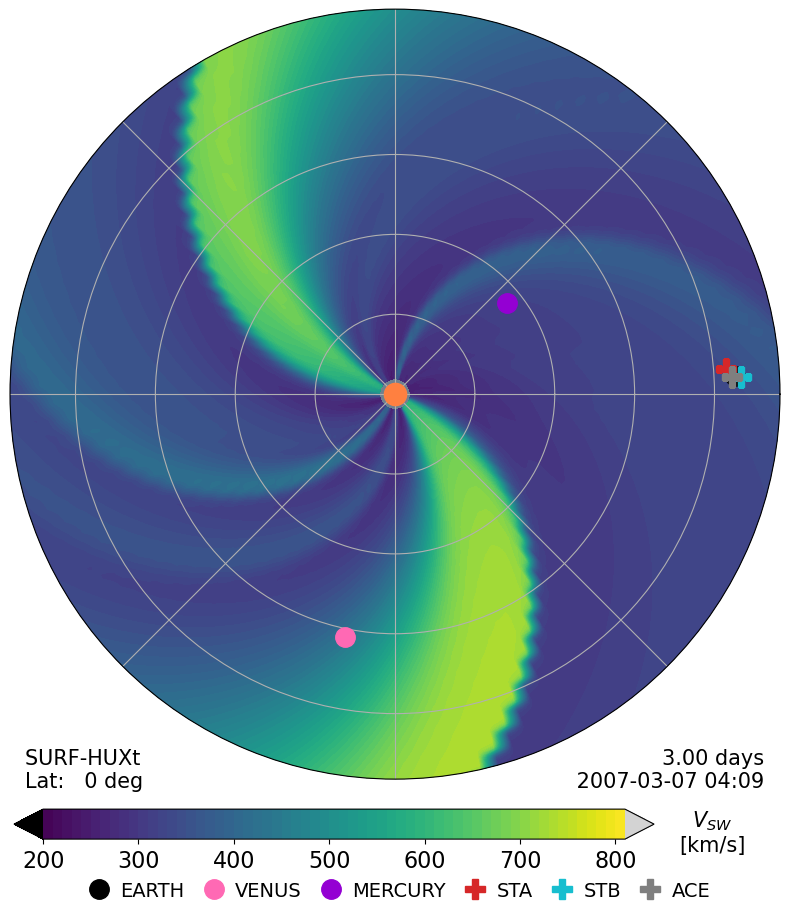

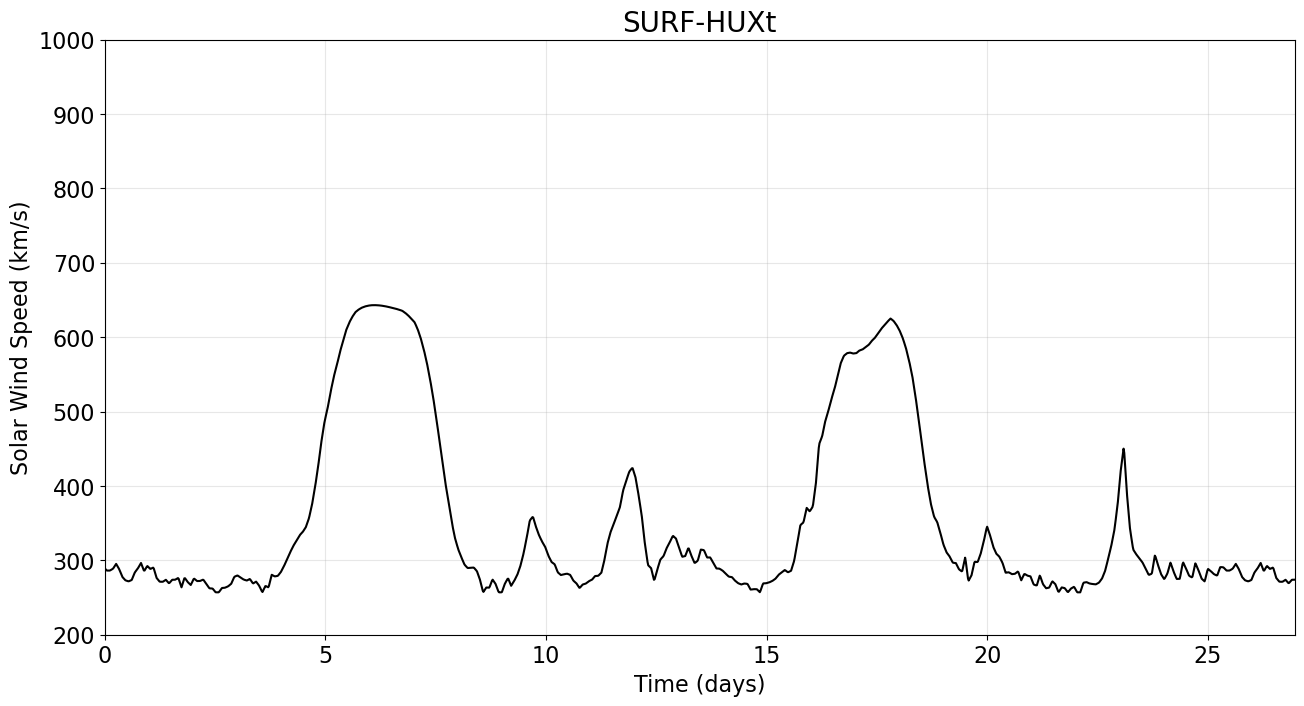

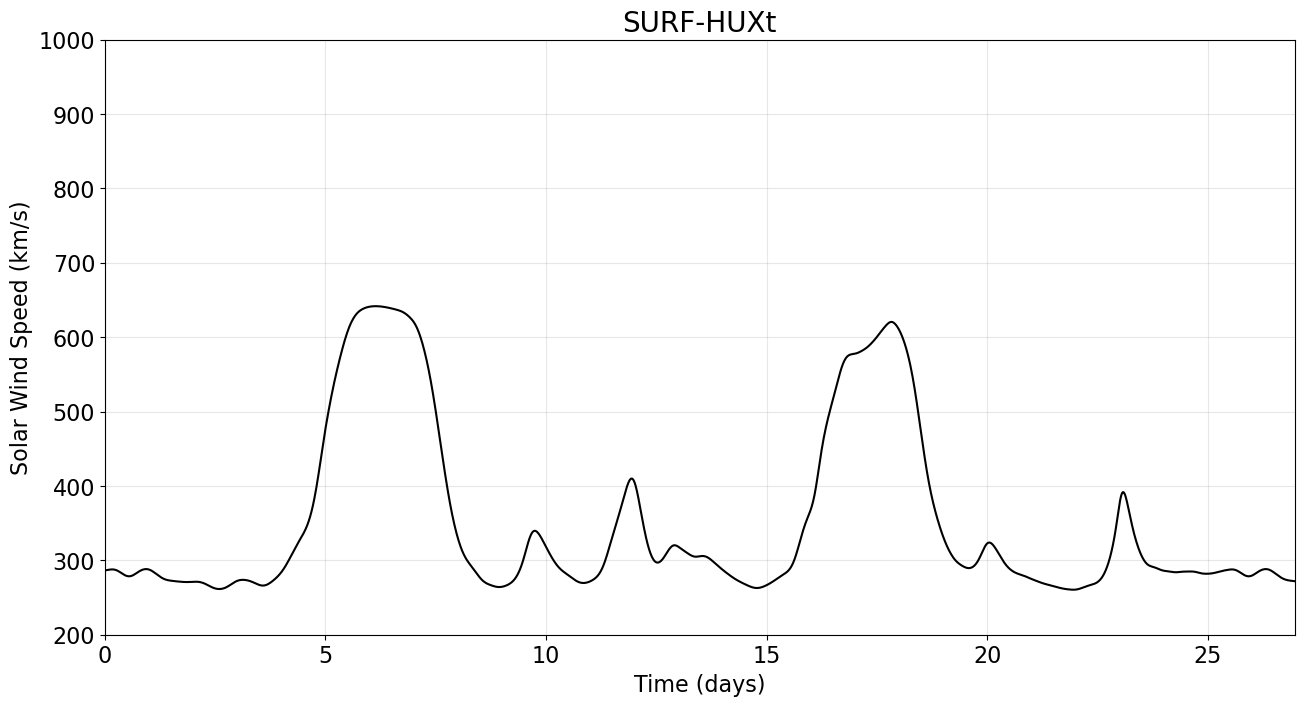

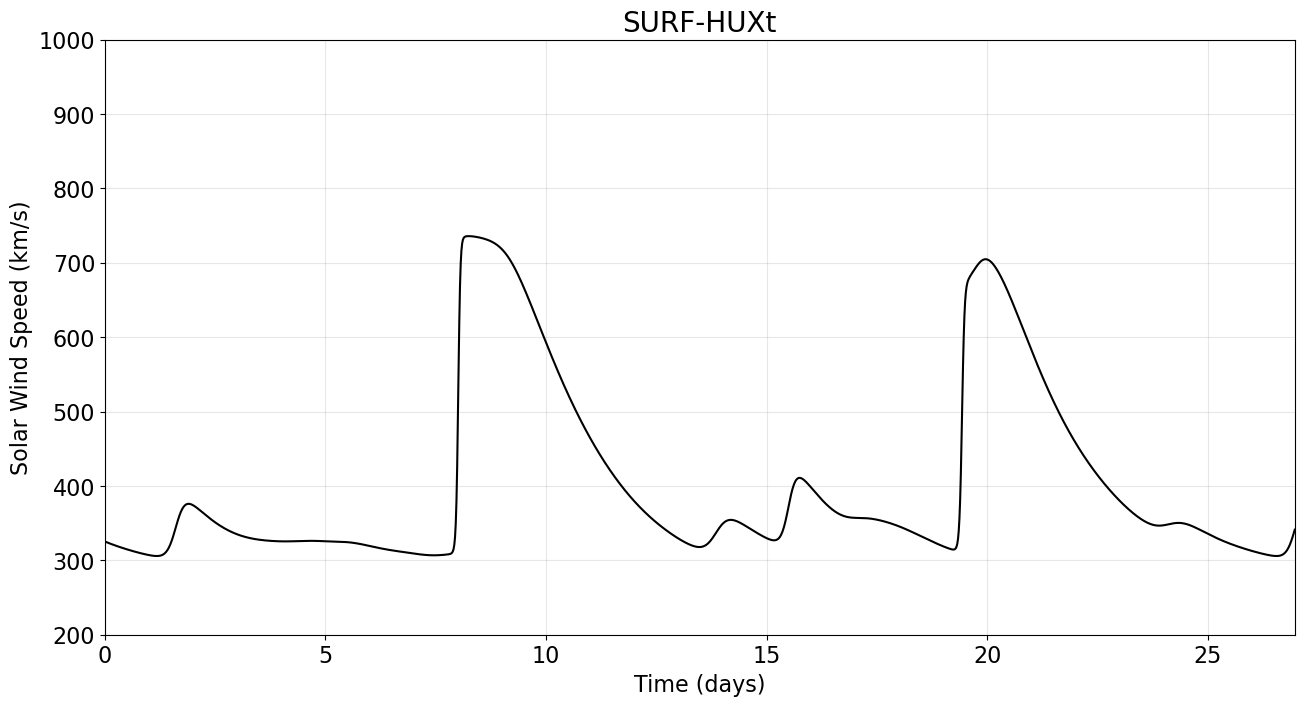

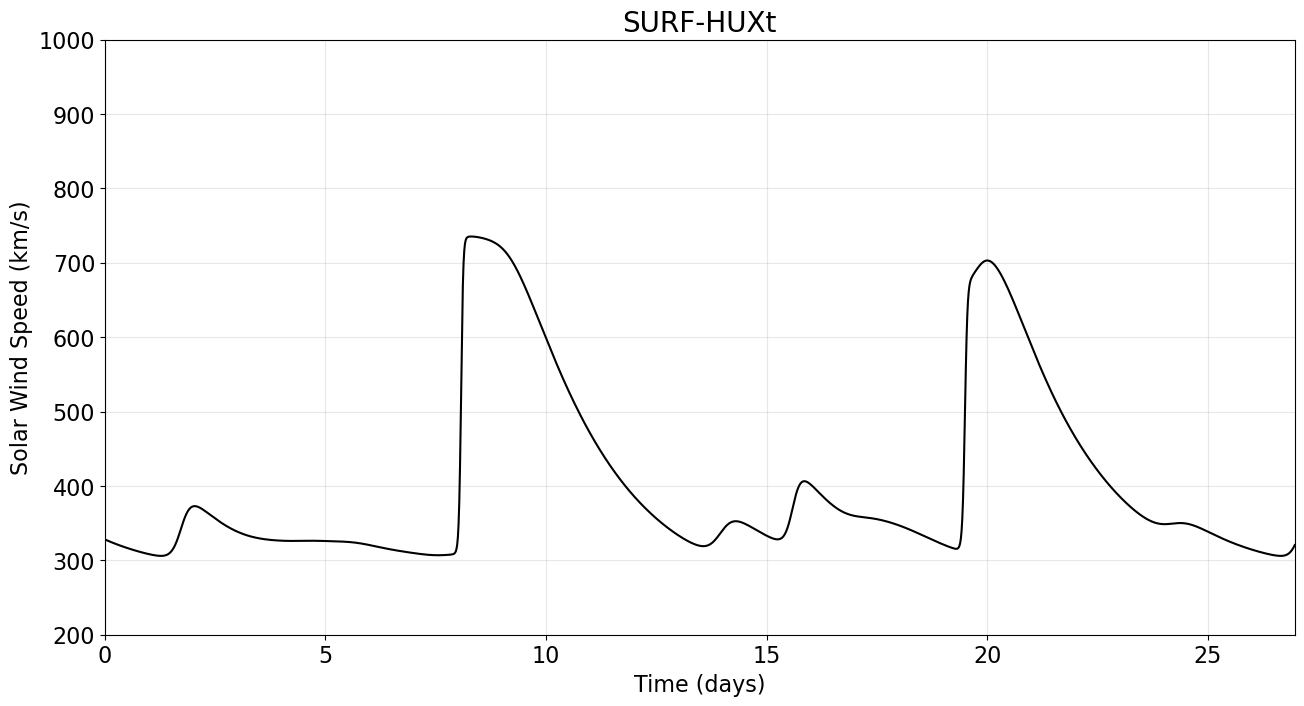

In [20]:
# Setup and run SURF for a standard 30Rs run
cr = 2054
vr_in = surfIN.get_MAS_long_profile(cr,0.0*u.deg)
model30 = surf.SURF(v_boundary=vr_in, r_min=30*u.solRad, cr_num=cr, latitude=0*u.deg, simtime=27*u.day, dt_scale=4, frame='sidereal')
model30.solve([]) 

# Map the inner boundary MAS values inwards from 30 rS to 10 rS
vr_10rs = surfIN.map_v_boundary_inwards(vr_in, 30*u.solRad, 10*u.solRad)

# Now setup SURF to run from 10Rs
model10 = surf.SURF(v_boundary = vr_10rs, cr_num=cr, simtime=27*u.day, 
                 latitude=0*u.deg, dt_scale=4, r_min=10*u.solRad, frame='sidereal')
model10.solve([])

# Plot the 30 and 21.5 rS solutions. (They should be the same, though not numerically identical)
t_interest=3*u.day
surfA.plot(model30, t_interest)
surfA.plot(model10, t_interest)

r = 30*u.solRad
surfA.plot_timeseries(model30, r, lon=0*u.deg)
surfA.plot_timeseries(model10, r, lon=0*u.deg)

r = 215*u.solRad
surfA.plot_timeseries(model30, r, lon=0*u.deg)
surfA.plot_timeseries(model10, r, lon=0*u.deg)

## Example 16.
<a id="example_16"></a>
SURF has support for tracing streaklines (equivalent to passive magnetic flux tubes) through a given velocity field

HDF5 files already exist for CR2254


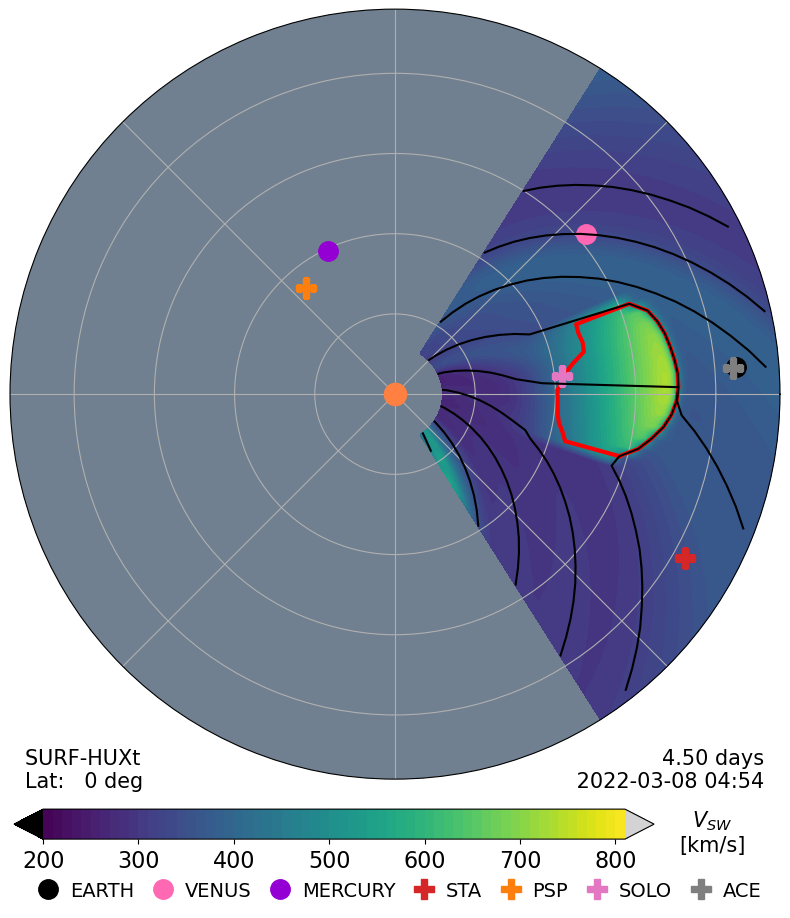

In [21]:
# Set up SURF
cr = 2254
vr_in = surfIN.get_MAS_long_profile(cr, 0.0*u.deg)
model = surf.SURF(v_boundary=vr_in, cr_num=cr, cr_lon_init = 50*u.deg, r_min=30*u.solRad, simtime=5*u.day, dt_scale=1, frame='sidereal', lon_start=300*u.deg, lon_stop=60*u.deg)
# Add a CME
cme = surf.ConeCME(t_launch=2.5*u.day, longitude=0.0*u.deg, width=40*u.deg, v=1000*(u.km/u.s), initial_height=30*u.solRad, thickness=5*u.solRad)
cme_list = [cme]

# Set up to trace a set of field lines from a range of evenly spaced Carrington longitudes
dlon = (20*u.deg).to(u.rad).value
lon_grid = np.arange(dlon/2, 2*np.pi-dlon/2 + 0.0001, dlon)*u.rad

# Give the streakline footpoints (in Carr long) to the solve method
model.solve(cme_list, streak_carr=lon_grid)

# Plot these streaklines
time = 4.5*u.day
fig, ax = surfA.plot(model,time, save = 'True', tag = 'CR2254_streaklines')

## Example 17.
<a id="example_17"></a>
The HCS position can be tracked as a streakline and the associated B_polarity grid computed

HDF5 files already exist for CR2254
HDF5 files already exist for CR2254


(<Figure size 1000x1000 with 2 Axes>, <PolarAxes: >)

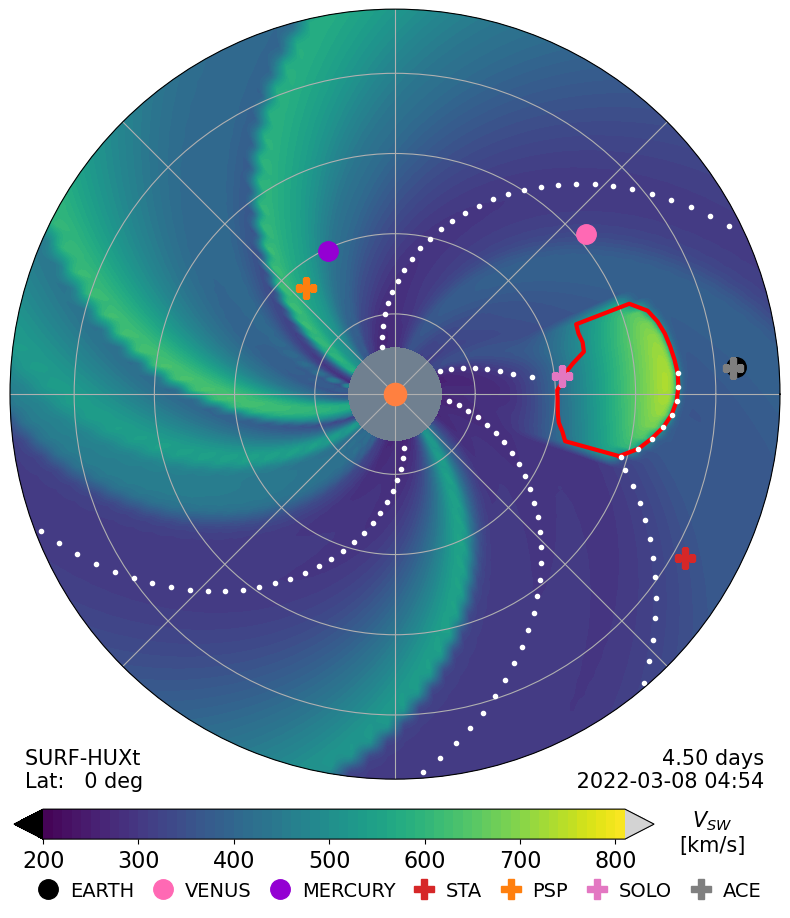

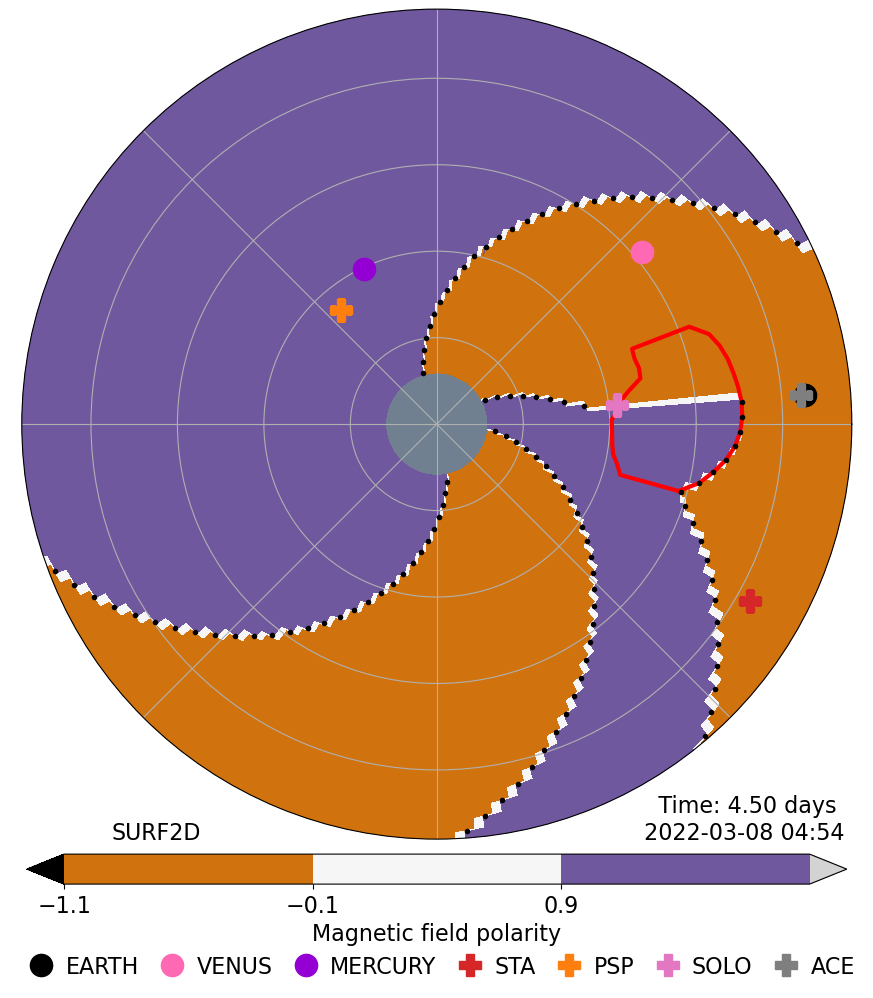

In [22]:
cr = 2254
vr_in = surfIN.get_MAS_long_profile(cr, 0.0*u.deg)
# Get the Br values from the HelioMAS solution
br_in = surfIN.get_MAS_br_long_profile(cr, 0.0*u.deg)  

model = surf.SURF(v_boundary=vr_in, b_boundary=br_in, cr_num=cr, cr_lon_init = 50*u.deg, r_min=30*u.solRad, simtime=5*u.day, dt_scale=1, frame='sidereal')
# Add a CME and solve
cme = surf.ConeCME(t_launch=2.5*u.day, longitude=0.0*u.deg, width=40*u.deg, v=1000*(u.km/u.s), initial_height=30*u.solRad, thickness=5*u.solRad)
cme_list = [cme]
model.solve(cme_list)

# Plot the speed solution, including the HCS
time = 4.5*u.day
surfA.plot(model, time)

# Plot the b-polarity grid
surfA.plot_bpol(model, time)

## Example 18.
<a id="example_18"></a>
Extract and plot the timeseries at Earth

HDF5 files already exist for CR2054
HDF5 files already exist for CR2054


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

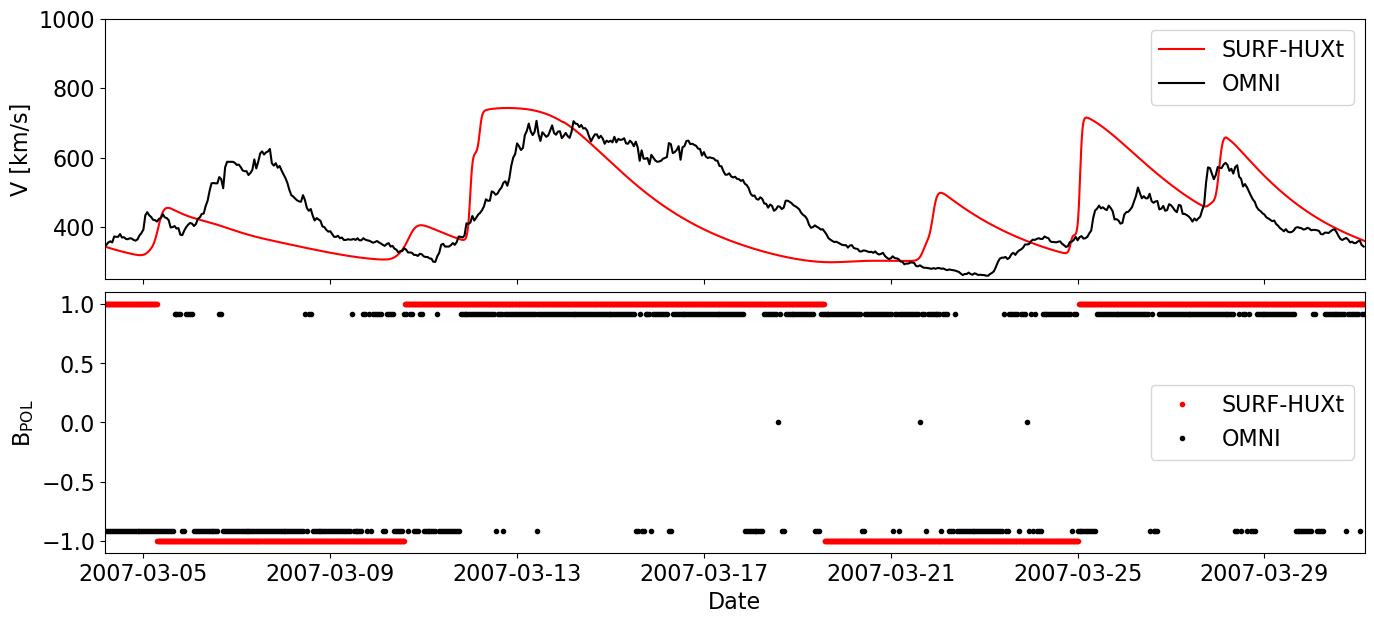

In [23]:
cr = 2054 # March, so Earth is around  - 7 degrees lat
lat = -7 * u.deg

vr_in = surfIN.get_MAS_long_profile(cr,lat)
# Get the Br values from the HelioMAS solution
br_in = surfIN.get_MAS_br_long_profile(cr, lat)  
# Now run SURF
model = surf.SURF(v_boundary=vr_in, b_boundary=br_in, cr_num=cr, latitude=lat, r_min=30*u.solRad, simtime=27*u.day, dt_scale=4, frame='sidereal')
model.solve([]) 

# The Earth time series can be plotted, along with OMNI data (downloaded on demand), using:
surfA.plot_earth_timeseries(model, plot_omni=True)

# The Earth time series can be extracted as a DataFrame using:
earth_series = surfA.get_observer_timeseries(model, observer='Earth')


## Example 19.
<a id="example_19"></a>

There is some limited support for running SURF in 3D. Currently this amounts to a wrapper class, `SURF3d`, that computes the longitudinal solutions for a range of latitudes. At present it isn't possible to render the CME coordinates in zonal slices. 

HDF5 files already exist for CR2000


2026-03-24 13:28:33 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2026-03-24 13:28:33 - matplotlib.animation - INFO: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1000x1000 -pix_fmt rgba -framerate 20.0 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y 'C:\Users\vy902033\AppData\Local\surf\figures\SURF_CR2000_model3d_3D_movie.mp4'


Rendering 200 frames. Expected time: 40 secs
mp4 file written to C:\Users\vy902033\AppData\Local\surf\figures\SURF_CR2000_model3d_3D_movie.mp4


(<Figure size 1000x1000 with 2 Axes>, <PolarAxes: >)

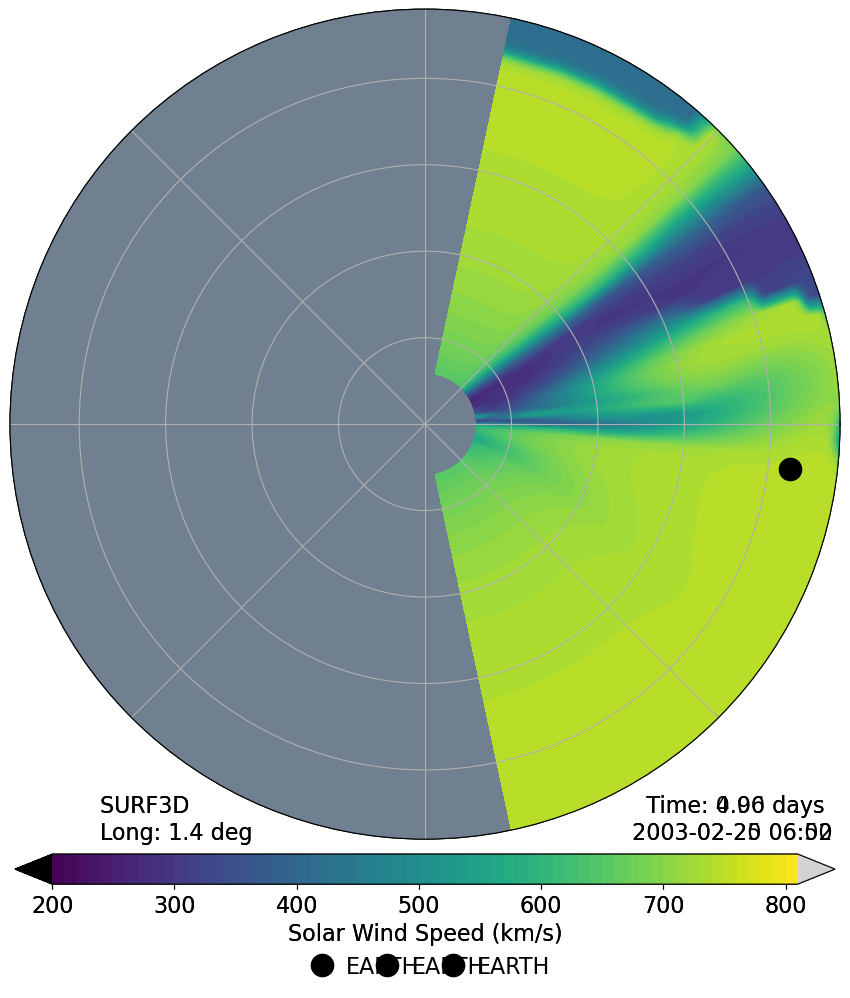

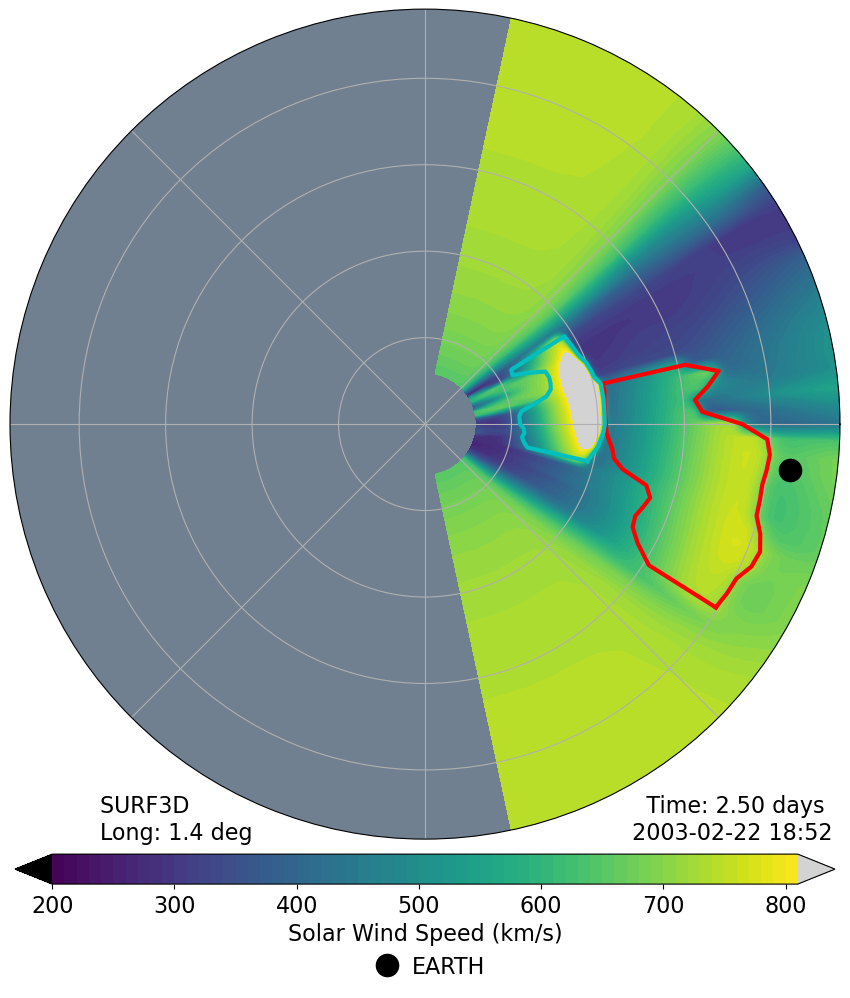

<Figure size 1000x1000 with 0 Axes>

In [24]:
# Set up a meridional cut run.
cr=2000
vmap, vlongs, vlats = surfIN.get_MAS_vr_map(cr)

model3d=surf.SURF3d(cr_num=cr,v_map=vmap, v_map_lat=vlats, v_map_long=vlongs,
                    latitude_max=90*u.deg, latitude_min=-90*u.deg, lon_start=300*u.deg, lon_stop=60*u.deg, 
                    simtime=5*u.day, r_min=30*u.solRad)

# Run the model with a couple of CMEs
cme1 = surf.ConeCME(t_launch=0.5*u.day, longitude=0.0*u.deg, latitude=-10*u.deg,
                width=50*u.deg, v=800*(u.km/u.s), thickness=5*u.solRad, initial_height=30*u.solRad)

cme2 = surf.ConeCME(t_launch=1.5*u.day, longitude=0.0*u.deg, latitude=10*u.deg,
                width=50*u.deg, v=1000*(u.km/u.s), thickness=5*u.solRad, initial_height=30*u.solRad)

cme_list = [cme1, cme2]
model3d.solve(cme_list)

# Produce a movie of r-lat cut at constant lon
surfA.animate_3d(model3d, lon=0*u.deg, tag='model3d')

# Plot r-lat cut at constant lon
t = 2.5*u.day
surfA.plot3d_radial_lat_slice(model3d, t, lon=0*u.deg)

# Each individual 2d solution can also be accessed and plotted in the same way as a standard SURF run.
# Extract and plot the equatorial plane
nlat = model3d.nlat
neq = int(np.floor(nlat / 2)) + 1
model = model3d.SURFlat[neq]

surfA.plot(model, t)

## Example 20.
<a id="example_20"></a>
SURF can be run from 1-AU outwards using OMNI observations as the inner boundary condition. Functions exist for downloading and processing the OMNI data, as well as setting up the model run. The same functionality can also be used for time-dependent boundary conditions from coronal models.

Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

(<Figure size 1000x1000 with 2 Axes>, <PolarAxes: >)

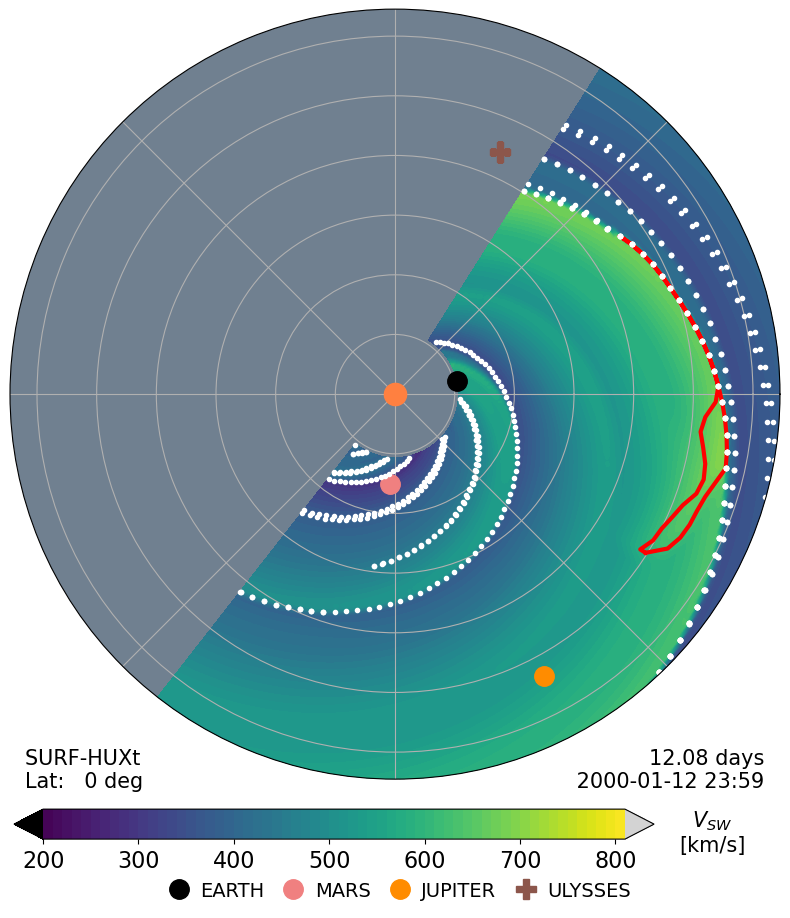

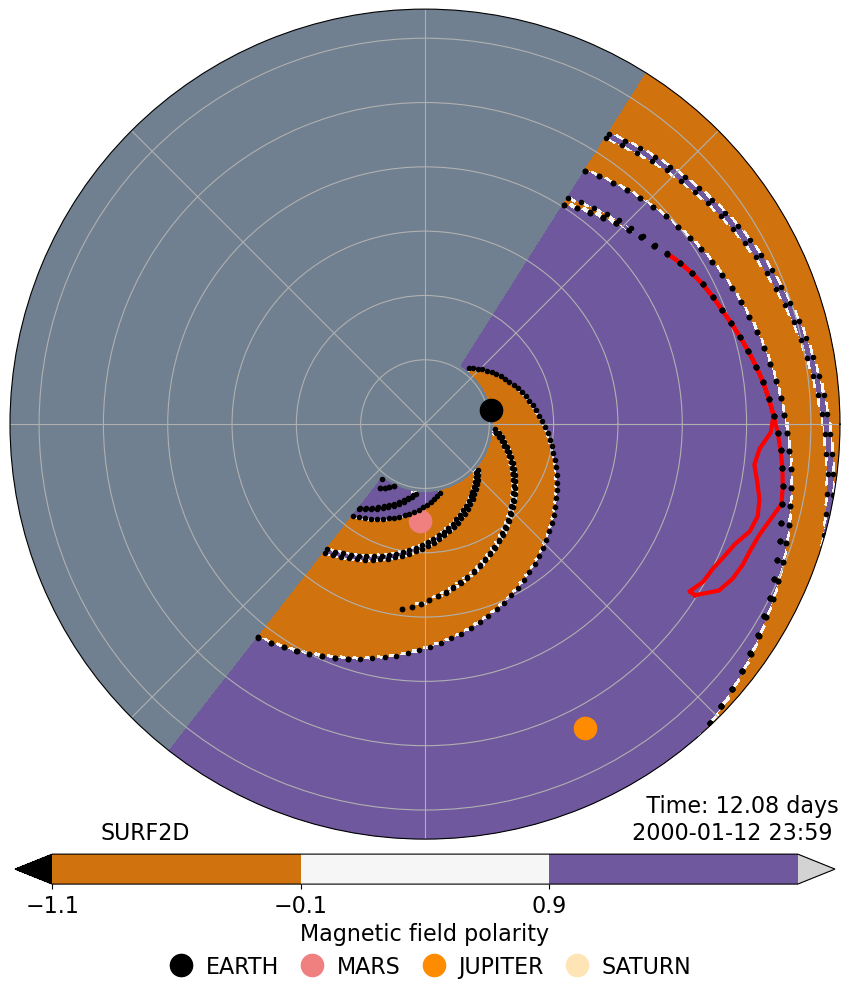

In [25]:
# Set up run start and end times to compute simulation time
runstart = datetime.datetime(2000,1,1)
runend = datetime.datetime(2000,1,15)
simtime = (runend-runstart).days * u.day
r_min = 215 *u.solRad

# Download and process the OMNI data
time, vcarr, bcarr = surfIS.generate_vCarr_from_OMNI(runstart, runend)

# Set up the model, with (optional) time-dependent bpol boundary conditions
model = surfIN.set_time_dependent_boundary(vcarr, time, runstart, simtime, 
                                        r_min=r_min, r_max=1290*u.solRad, dt_scale=50, latitude=0*u.deg,
                                       bgrid_Carr = bcarr, lon_start=230*u.deg, lon_stop=60*u.deg,)

# CME properties must be specified relative to the inner boundary (i.e. time at 1 AU and angles relative to Earth)
cme = surf.ConeCME(t_launch=1.5*u.day, longitude=0.0*u.deg, latitude=0.0*u.deg,
                width=70*u.deg, v=800*(u.km/u.s), thickness=2*u.solRad, initial_height=r_min)

model.solve([cme]) #can take a couple of minutes to process the input data and solve the model out to Jupiter for 3 months

surfA.plot(model, 12*u.day)
surfA.plot_bpol(model, 12*u.day)

## Example 21.
<a id="example_21"></a>
The Earth-connected streak line can be traced in an existing SURF run

HDF5 files already exist for CR2254


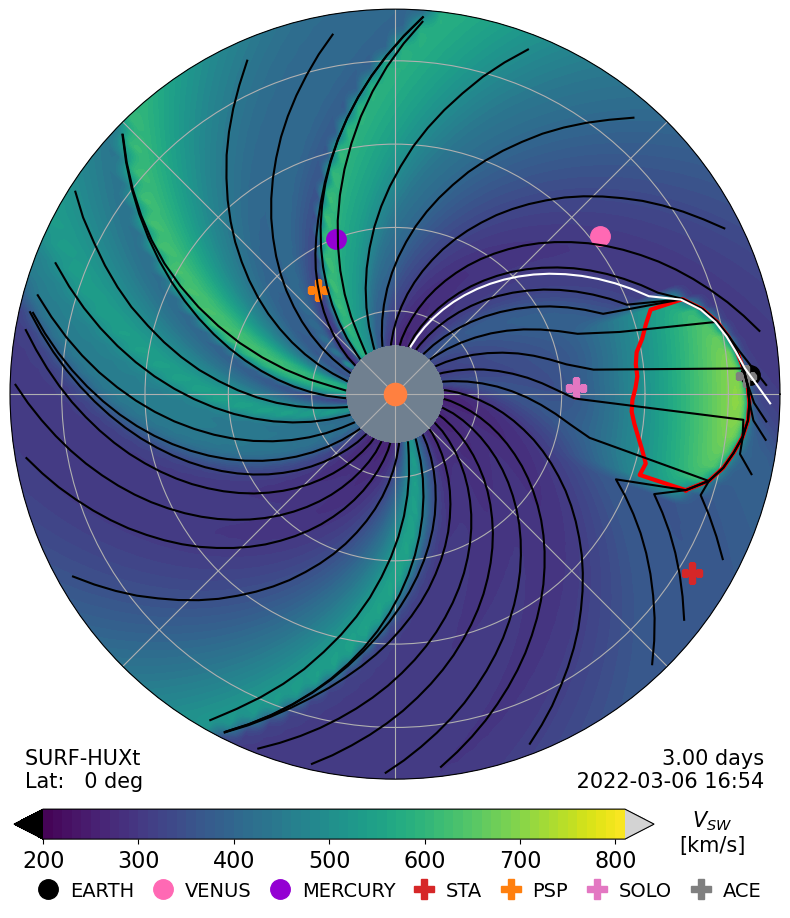

In [26]:
# Set up SURF with a CME and solve, also tracing fieldlines
cr = 2254
vr_in = surfIN.get_MAS_long_profile(cr, 0.0*u.deg)
model = surf.SURF(v_boundary=vr_in, cr_num=cr, cr_lon_init = 50*u.deg, r_min = 30*u.solRad, simtime=4*u.day, r_max=230*u.solRad, dt_scale=1, frame='sidereal')
cme = surf.ConeCME(t_launch=0.5*u.day, longitude=0.0*u.deg, width=40*u.deg, v=1000*(u.km/u.s), thickness=5*u.solRad, initial_height=30*u.solRad)
cme_list = [cme]
lon_grid = (np.arange(0.5, 359.5, 10)*u.deg).to(u.rad)
model.solve(cme_list, streak_carr = lon_grid)

# Find the Earth-connected field line and plot
time = 3*u.day
fig, ax = surfA.plot(model, time)
plotlon, plotr, optimal_lon, optimal_t = surfA.find_Earth_connected_field_line(model, time)
ax.plot(plotlon, plotr, 'w-')

# You can also create a movie of the Earth-connected field line.
# This can take several minutes, as computing the earth connected field line is comparatively expensive.
# Uncomment the line below to produce this movie. 
# surfA.animate(model, tag='trace_earth_connection_test', trace_earth_connection=True)


## Example 22.
<a id="example_22"></a>
Driving SURF with OMNI data using dynamic time warping

Files Downloaded:   0%|          | 0/6 [00:00<?, ?file/s]

(<Figure size 1000x1000 with 2 Axes>, <PolarAxes: >)

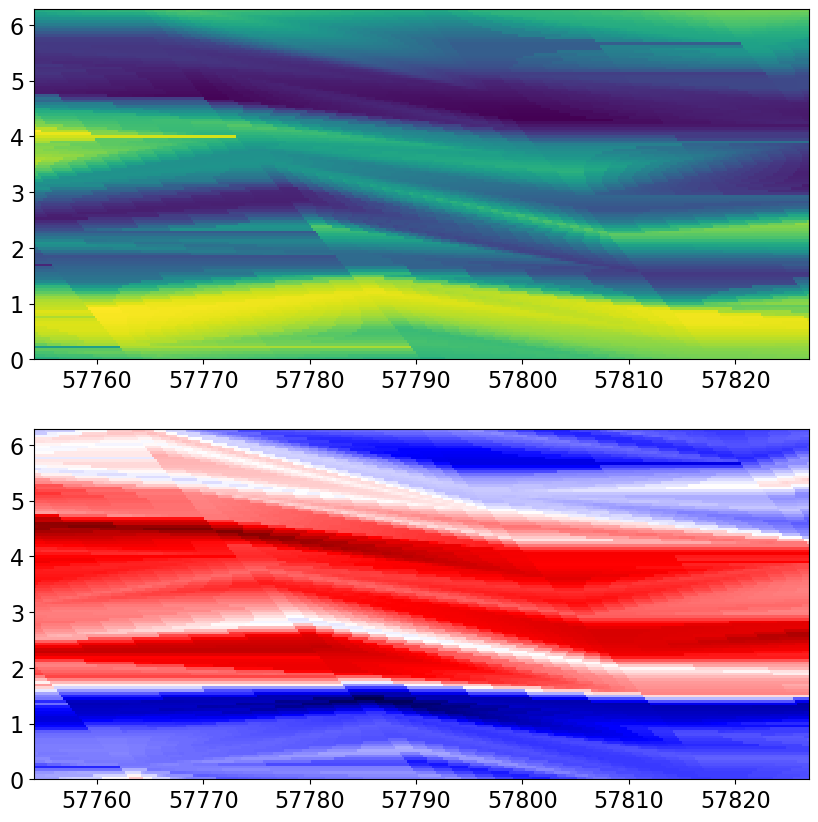

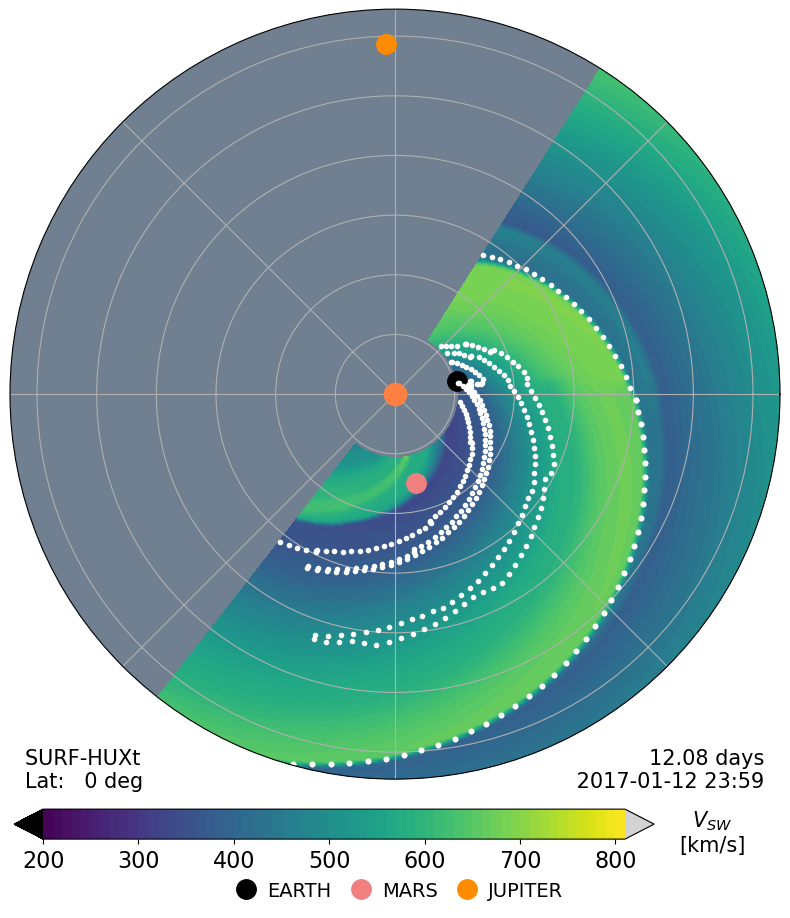

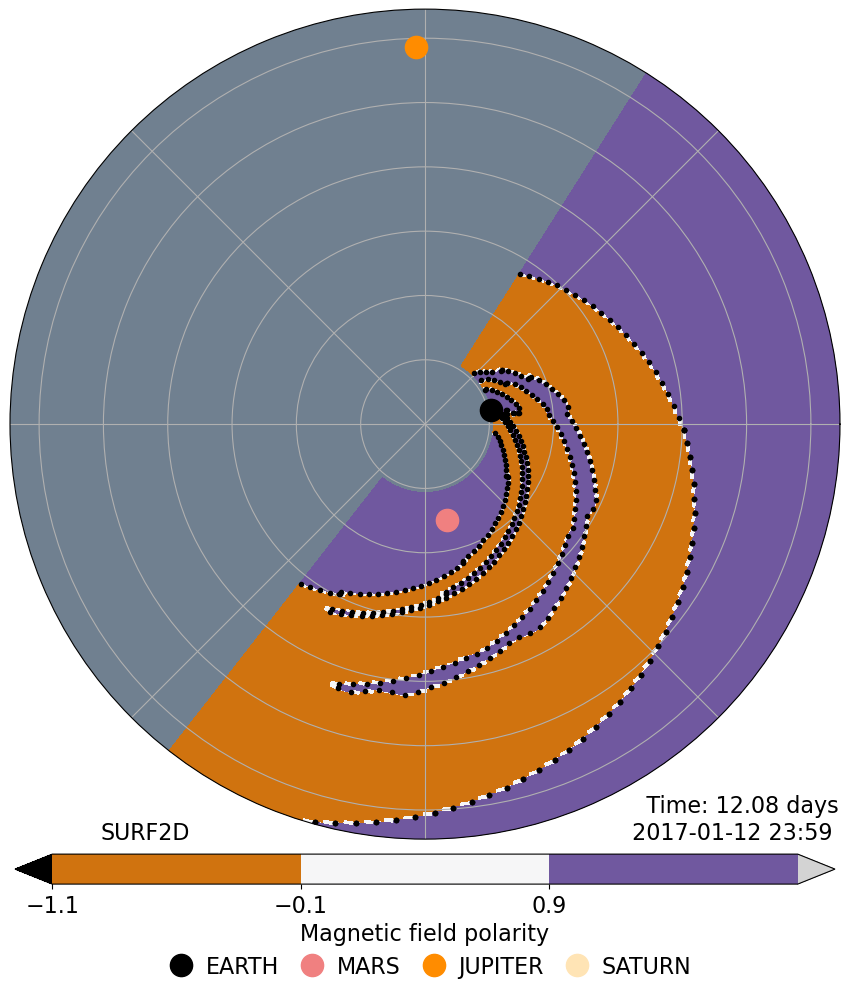

In [27]:
# Example 22. Use OMNI to drive a SURF run.

runstart = datetime.datetime(2017,1,1)
runend = datetime.datetime(2017,3,15)
simtime = (runend-runstart).days * u.day
r_min = 215 *u.solRad
psi_days = 7*u.day
max_warp_days = 7*u.day
dtw_on = 'Vpol'

# Download the OMNI data
starttime = runstart - datetime.timedelta(days=28 + psi_days.value)
endtime = runend + datetime.timedelta(days=28+ psi_days.value)
omni = surfIS.get_omni(starttime, endtime)

# Add a new omni field for determining teh DTW paths, using info from both speed and magnetic field polarity
omni['Vpol'] = omni['V']*np.sign(omni['BX_GSE'])

# Download and process the OMNI data
time, carr_lon, vcarr, bcarr = surfIS.generate_vCarr_from_OMNI_DTW(runstart, runend, psi_days=psi_days,  max_warp_days=max_warp_days,
                                                                omni_input=omni, dtw_on=dtw_on)

# Plot the determined boundary conditions
fig, axs  = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))
axs[0].pcolormesh(time, carr_lon, vcarr, shading='auto', cmap='viridis') 
axs[1].pcolormesh(time, carr_lon, bcarr, shading='auto', cmap='seismic') 


# Set up the model, with (optional) time-dependent bpol boundary conditions
model = surfIN.set_time_dependent_boundary(vcarr, time, runstart, simtime, r_min=r_min, r_max=1290*u.solRad, dt_scale=50,
                                        latitude=0*u.deg, bgrid_Carr = bcarr, lon_start=230*u.deg, lon_stop=60*u.deg,)

model.solve([]) # It can take a few of minutes to process the input data and solve the model out to Jupiter for 3 months

surfA.plot(model, 12*u.day)
surfA.plot_bpol(model, 12*u.day)

## Example 23.
<a id="example_23"></a>
ConeCMEs can be set to have an expanding profile (velocity perturbation deccreases through the CME), and/or a fixed duration. The fixed duration alleviates an unfortunate "feature" of the Cone CME geometry where slower CMEs result in longer perturbations at the inner boundary, and speed profiles throughout the CME which struggle to match observed speed profiles.  

No initiation time specified. Defaulting to start of CR2000, 20/2/2003


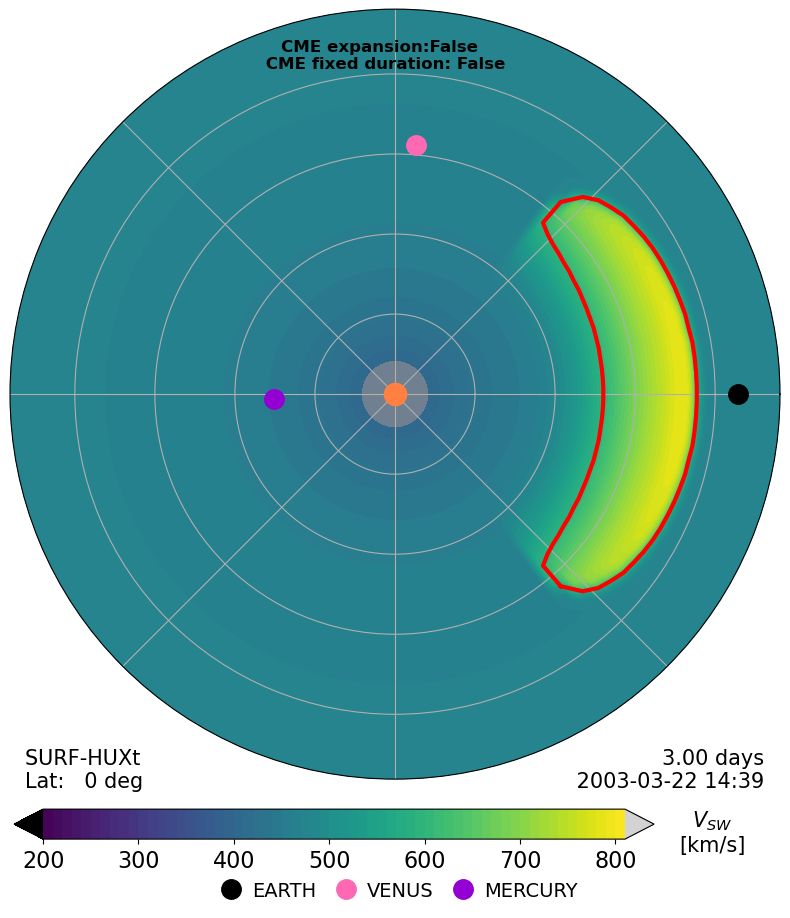

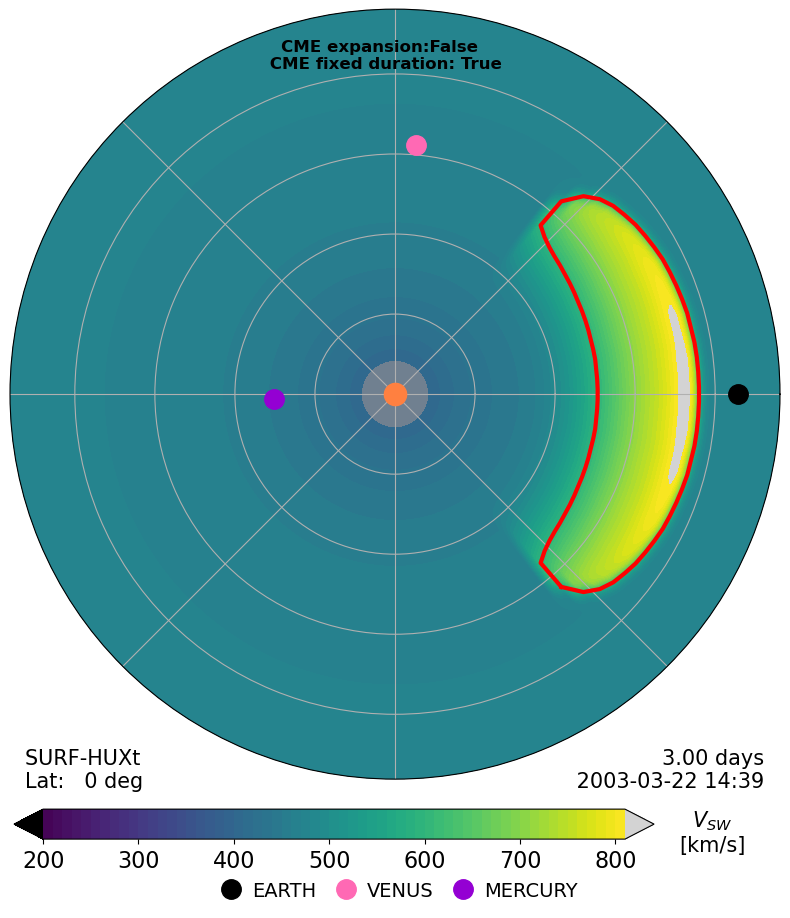

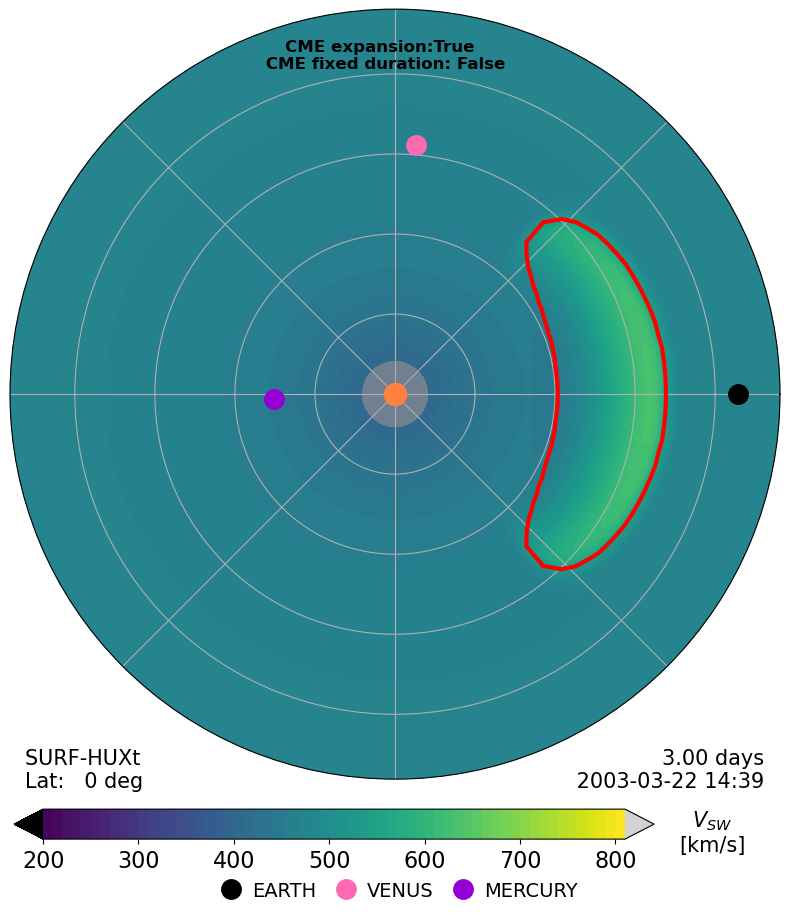

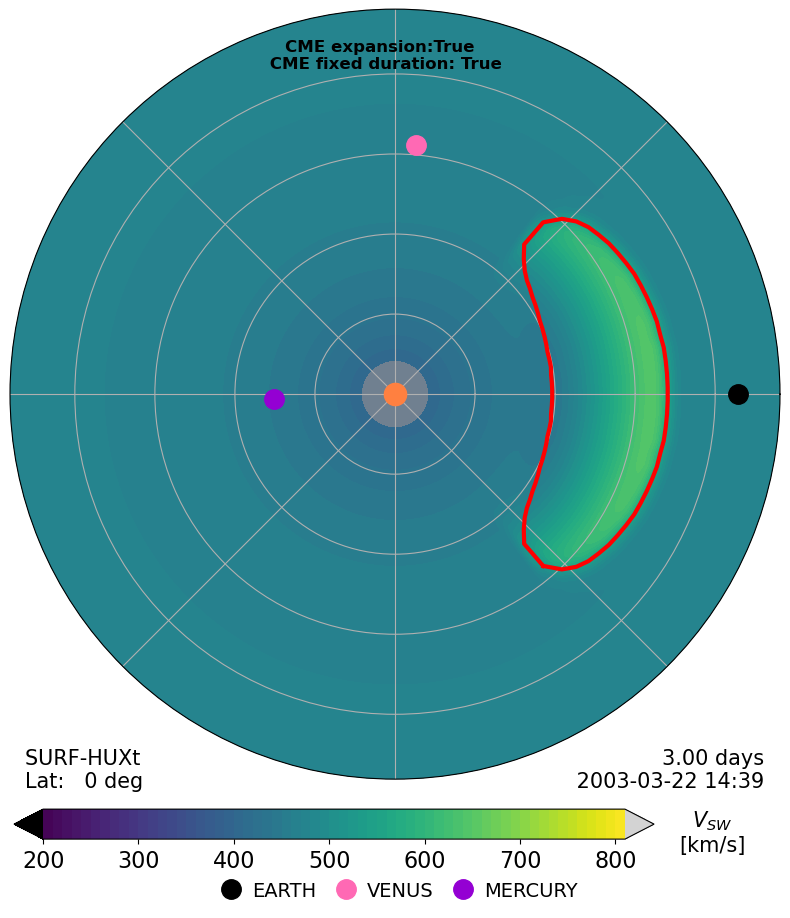

In [28]:
# Form boundary conditions - background wind of 400 km/s
v_boundary = np.ones(128) * 400 * (u.km/u.s)

# Setup SURF to do a 4-day simulation, with model output every 4 timesteps (roughly half and hour time step)
model = surf.SURF(v_boundary=v_boundary, latitude = 0*u.deg, simtime=4*u.day, dt_scale=4)

for cme_expansion in [False, True]:
    for cme_fixed_duration in [False, True]:
        #  Add a CME
        cme = surf.ConeCME(t_launch=1*u.day, longitude=360*u.deg, latitude = 0*u.deg, width=100*u.deg, v=1000*(u.km/u.s), 
                        thickness=5*u.solRad, cme_expansion=cme_expansion, cme_fixed_duration=cme_fixed_duration)

        model.solve([cme], tag='cone_cme_expand_{}_fixed_duration_{}'.format(cme_expansion, cme_fixed_duration))
        # Plot this out
        t_interest = 3*u.day
        fig, ax = surfA.plot(model, t_interest)
        label = 'CME expansion:{} \n CME fixed duration: {}'.format(cme_expansion, cme_fixed_duration)
        fig.suptitle(label, y=0.95, color='k', fontweight='bold')

## Example 24.
<a id="example_24"></a>
SURF can generate time-dependent boundary conditions from a directory of WSA solutions

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: ylabel='V [km/s]'>,
        <Axes: xlabel='Date', ylabel='B$_{\\text{POL}}$'>], dtype=object))

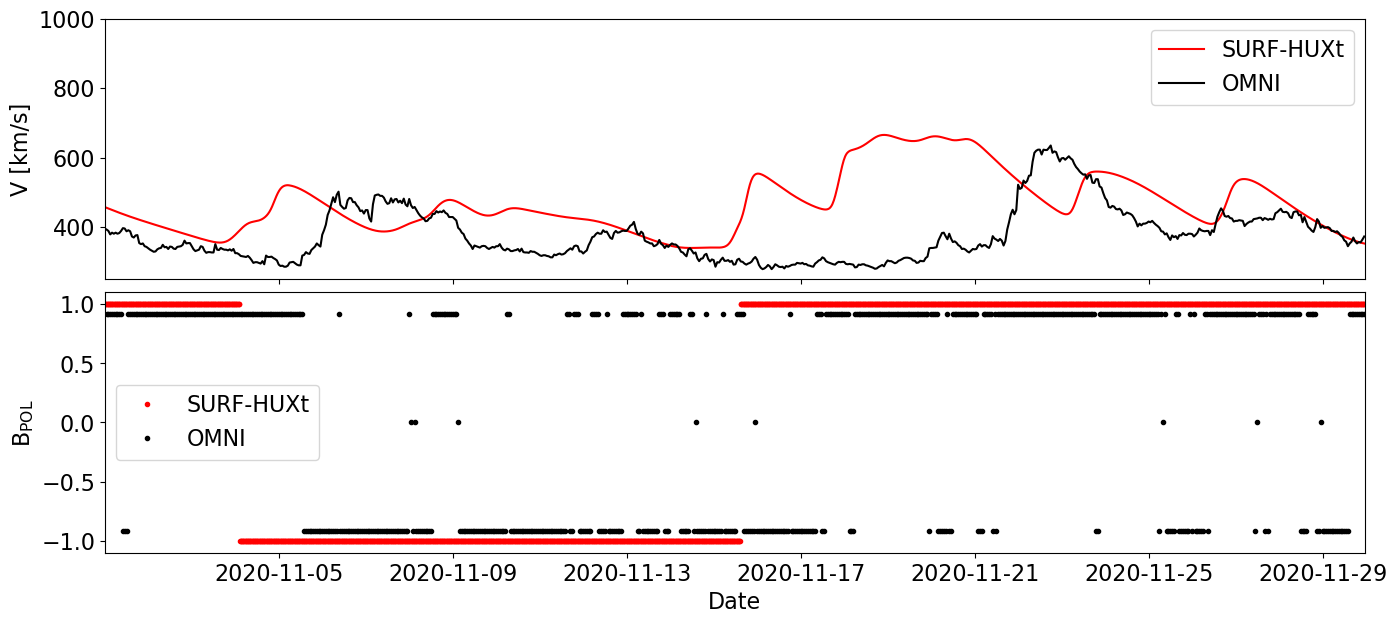

In [29]:
# Start and end times for the run
start_dt = datetime.datetime(2020,11,1)
stop_dt = datetime.datetime(2020,11,30)
simtime = ((stop_dt - start_dt).days)*u.day

# Specify the data location and the file name convention
demo_dir = surf._setup_dirs_()['example_inputs']
wsa_dir = os.path.join(demo_dir, 'WSA_GONGZ')
vel_format_template = "vel_YYYYMMDDHHmmR000_gongz.fits"

# Get Earth latitude
latitude = surfIN.get_earth_lat(start_dt)

# Generate the time-dependent inner boundary conditions
vlongs, brlongs, lon, mjds, times = surfIN.surf_td_input_from_WSA_runs(wsa_dir, start_dt, stop_dt,
                                                                    latitude= latitude, deacc=True,
                                                                    format_template = vel_format_template)

# Set up the model, with time-dependent boundary conditions
model = surfIN.set_time_dependent_boundary(vlongs, mjds, start_dt, simtime, 
                                        r_min=21.5*u.solRad, r_max=230*u.solRad,
                                        bgrid_Carr=brlongs,
                                        dt_scale=4, latitude=latitude,
                                        frame='sidereal')
# Solve with some streaklines
dlon = (20*u.deg).to(u.rad).value
lon_grid = np.arange(dlon/2, 2*np.pi-dlon/2 + 0.0001, dlon)*u.rad
model.solve([],  streak_carr = lon_grid)

# Plot the timeseries
surfA.plot_earth_timeseries(model)

# Uncomment the line below to generate a movie - this will take several minutes. 
# surfA.animate(model, tag='SURF_WSA_time_dependent', duration=30, fps=20, plotHCS=False, trace_earth_connection=False)

## Example 25.
<a id="example_25"></a>
The example above is 2D - it assumes Earth remains in the same plain for the entire period. It is also possible to run SURF for a "wedge" of lat, lon and r values to allow for an object's motion over the run duration.

2026-03-24 13:35:53 - sunpy - INFO: Obtained JPL HORIZONS location for Earth (399)                    


INFO: Obtained JPL HORIZONS location for Earth (399)                     [sunpy.coordinates.ephemeris]
Runnig SURF at lat = 0.0 degrees
time outside model domain
time outside model domain
Runnig SURF at lat = 2.0 degrees
time outside model domain
time outside model domain
Runnig SURF at lat = 4.0 degrees
time outside model domain
time outside model domain


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

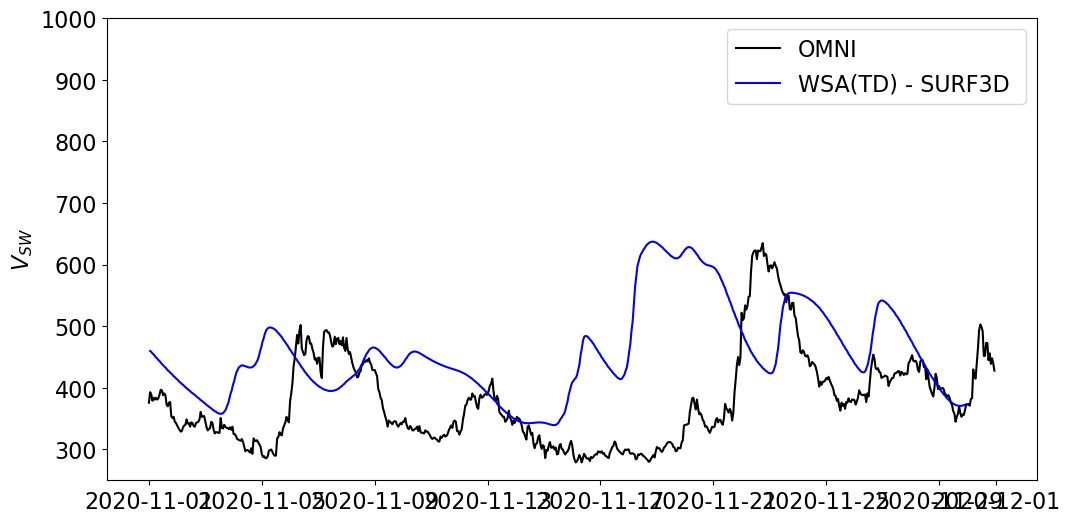

In [2]:
# Start and end times for the run
start_dt = datetime.datetime(2020,11,1)
stop_dt = datetime.datetime(2020,11,30)
simtime = (stop_dt - start_dt).days * u.day

# Specify the data location and the file name convention
demo_dir = surf._setup_dirs_()['example_inputs']
wsa_dir = os.path.join(demo_dir, 'WSA_GONGZ')
vel_format_template = "vel_YYYYMMDDHHmmR000_gongz.fits"


# Create and run a wedge of lat/lon containing Earth. return the time series
surf_ts = surfA.run_WSA_SURF_td_wedge_about_observer(start_dt, stop_dt, wsa_dir, 
                                                  vel_format_template,
                                                  obj='Earth',
                                                  deacc=True, dlat=2*u.deg)

# Grab omni data for comparison
omni = surfIS.get_omni(start_dt, stop_dt)

# Plot the timeseries
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(omni['datetime'], omni['V'], 'k', label = 'OMNI')
ax1.plot(surf_ts['time'], surf_ts['vsw'], 'b', label = 'WSA(TD) - SURF3D ')
ax1.set_ylim((250,1000))
ax1.set_ylabel(r'$V_{SW}$')
ax1.legend()

## Example 26.
<a id="example_26"></a>
SURF can be run with compressible hydrodynamic solvers. Use solver='hydro' for the second-order HLLC+PLM scheme, or solver='hydro-pcm' for the HLLC+PCM scheme. Density and temperature at the inner boundary can either be user-specified or computed from statistical relations with the radial speed at 21.5 rsurf. Similarly, for CMEs, the density and temperature can be specified or default values used.

Compressible SURF runs are about x3 longer runtime than the incompressible huxt solver.

Incompressible 2D SURF runs can be done in parallel on multi-CPU machines. This is not efficient for compressible SURF runs

c:\Users\vy902033\Dropbox\python_repos\HUXt5\HUXt\surf\data\example_inputs
No initiation time specified. Defaulting to start of CR2000, 20/2/2003
[OK] Compressible solver (hydro: HLLC+PLM) available
No initiation time specified. Defaulting to start of CR2000, 20/2/2003

USING COMPRESSIBLE SOLVER: HYDRO
Method: hllc-plm-rk2
Frame: synodic
Parallel: False



(<Figure size 2400x800 with 6 Axes>,
 array([<PolarAxes: >, <PolarAxes: >, <PolarAxes: >], dtype=object))

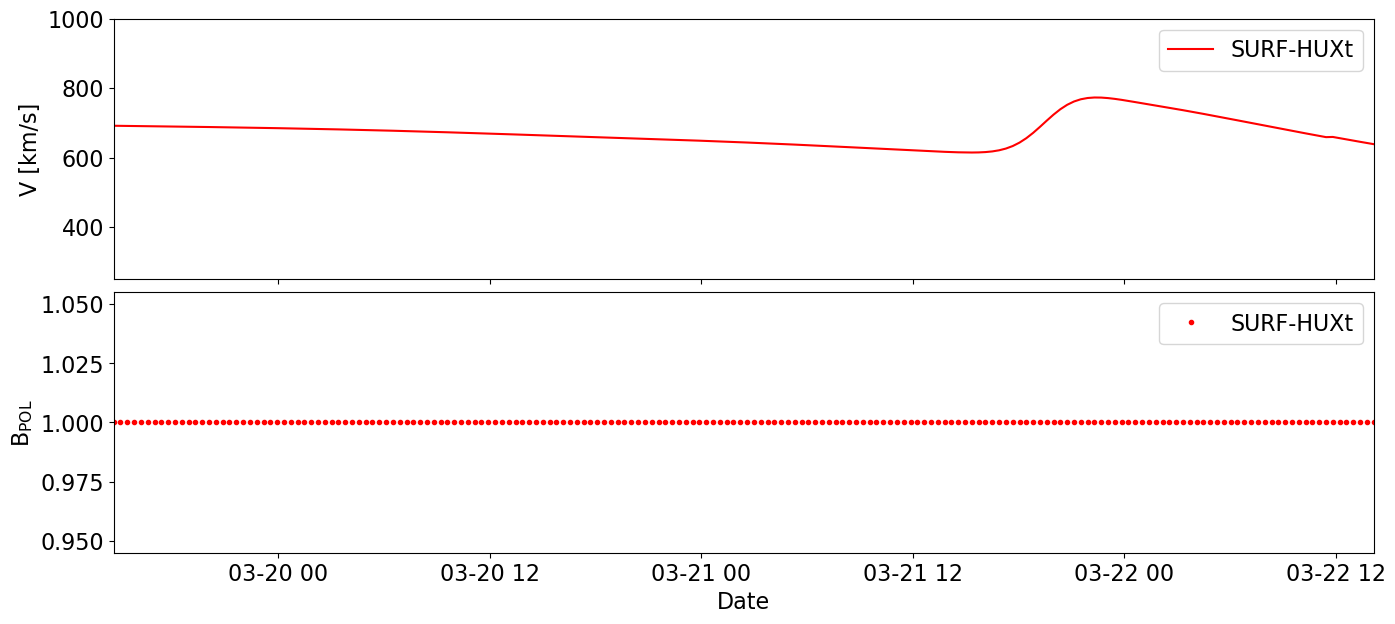

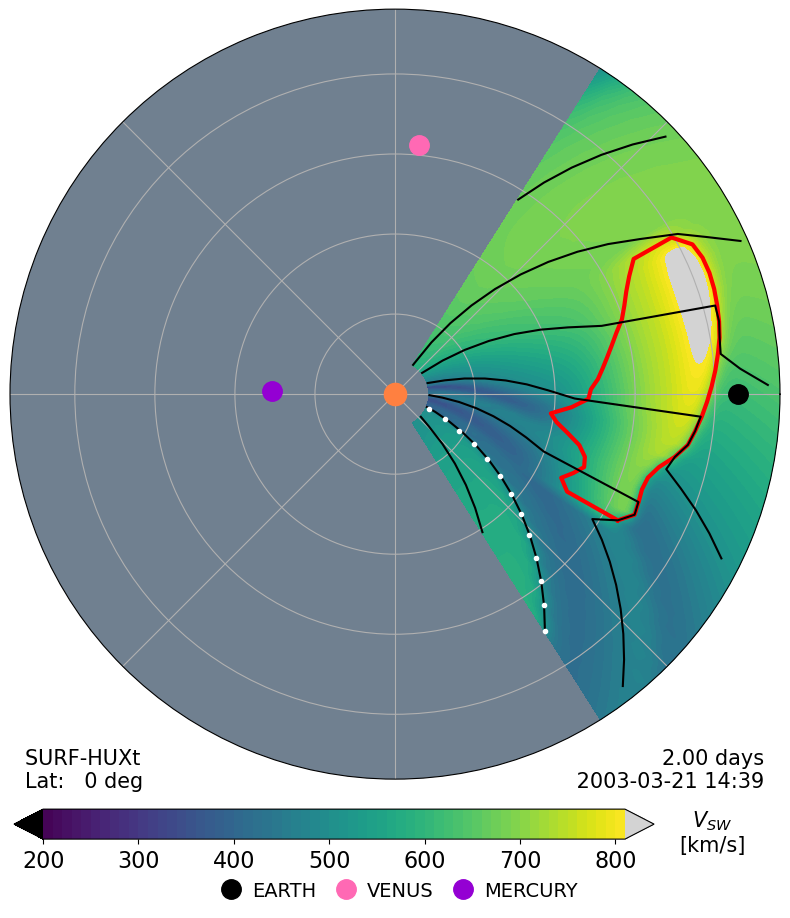

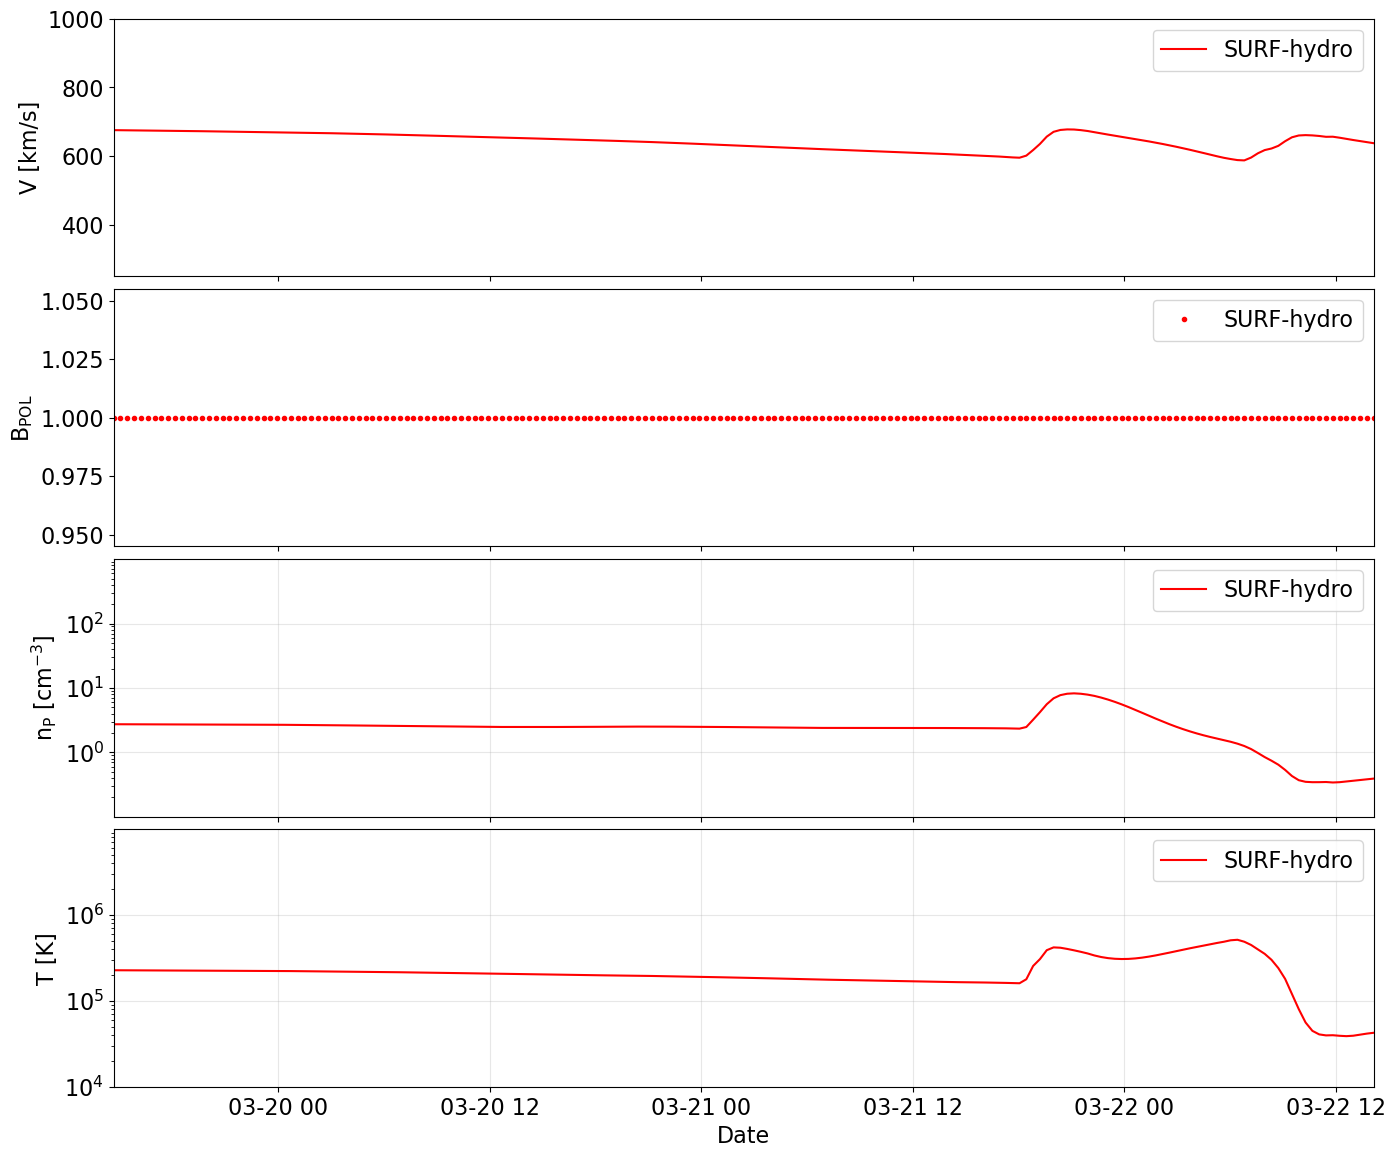

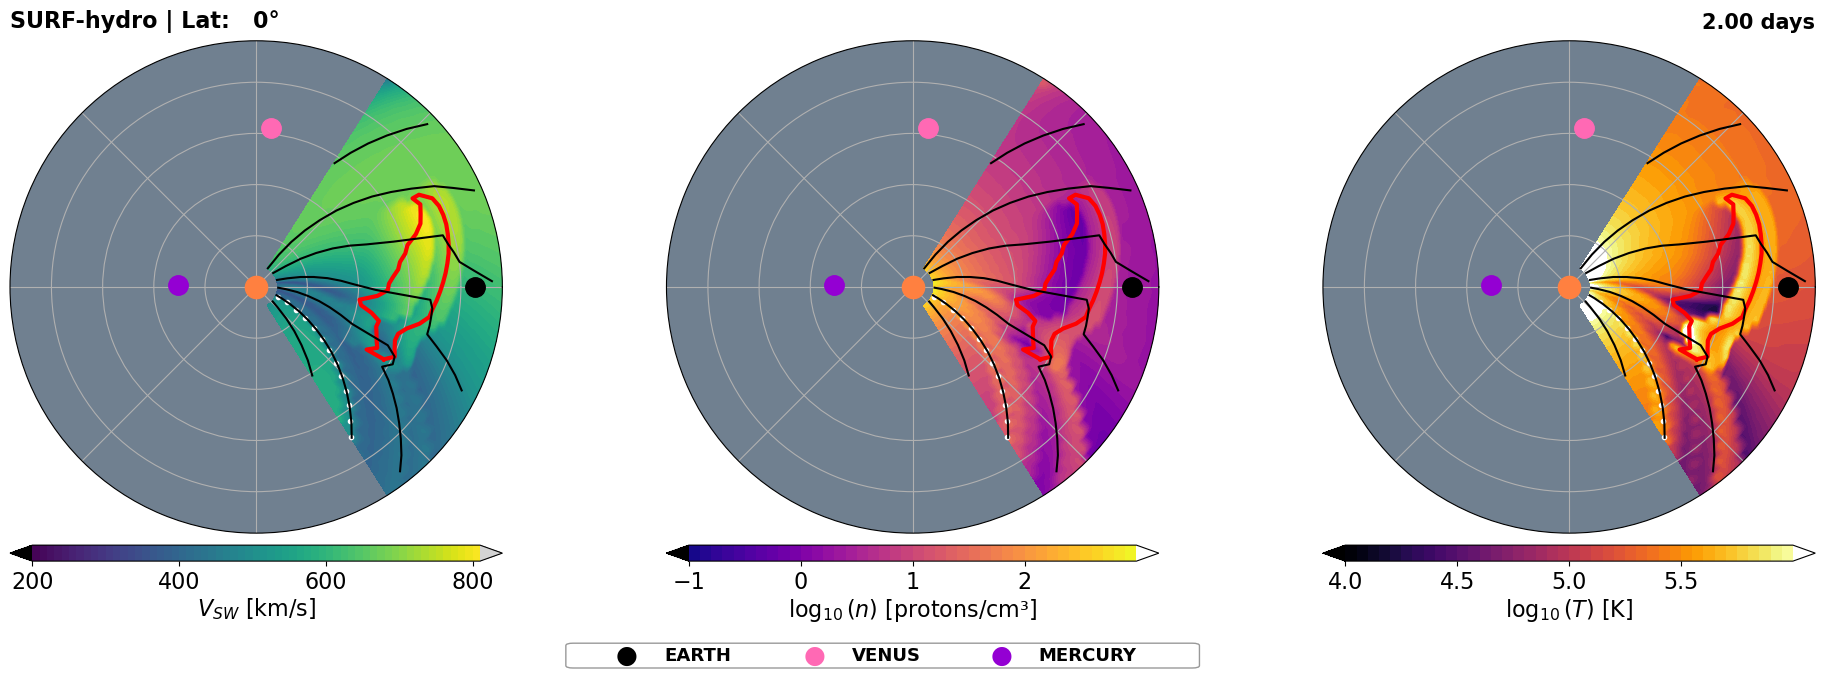

In [3]:
 # Set up the inner boundary conditions from WSA-GONG in the example_inputs dir
dirs = surf._setup_dirs_()
data_path=dirs['example_inputs']
print(data_path)
filepath = os.path.join(data_path, 'wsa_gong_2024050906.fits')
vr_in = surfIN.get_WSA_long_profile(filepath, lat=0.0 * u.deg)
br_in = surfIN.get_WSA_br_long_profile(filepath, lat=0.0 * u.deg)


# Set up to trace a set of field lines from a range of evenly spaced Carrington longitudes
dlon = (20*u.deg).to(u.rad).value
lon_grid = np.arange(dlon/2, 2*np.pi-dlon/2 + 0.0001, dlon)*u.rad
simtime = 3*u.day

# Get a list of two ConeCMEs
daysec = 86400
times = [0*u.day]
speeds = [1000]
lons = [0]
widths = [60]
thickness = [5]
cme_list = []
for t, l, w, v, thick in zip(times, lons, widths, speeds, thickness):
    cme = surf.ConeCME(t_launch=t, longitude=l*u.deg, width=w*u.deg, v=v*u.km/u.s, 
                    thickness=thick*u.solRad, 
                    density_fraction=0.1, temperature_fraction=0.1, 
                    profile_type='sinusoidal')
    cme_list.append(cme)


# solve for original SURF (incompressible solver)
model_incomp = surf.SURF(v_boundary=vr_in, b_boundary=br_in, 
                      lon_start=300*u.deg, lon_stop = 60*u.deg, 
                    simtime=simtime, dt_scale=4, 
                    solver ='huxt', parallel=True)
model_incomp.solve(cme_list, streak_carr=lon_grid)

#plot the results
t_interest = 2*u.day
surfA.plot_earth_timeseries(model_incomp, plot_omni=False)
surfA.plot(model_incomp, time=t_interest)

model_comp = surf.SURF(v_boundary=vr_in, b_boundary=br_in,
                    lon_start=300*u.deg, lon_stop = 60*u.deg,
                        simtime=simtime, dt_scale=4, 
                    solver ='hydro')

model_comp.solve(cme_list, streak_carr=lon_grid)
#plot the results
surfA.plot_earth_timeseries(model_comp, plot_omni=False)
surfA.plot_compressible(model_comp, time=t_interest)


## Example 27.
<a id="example_27"></a>
SURF can use OMNI observations to generate inner boundary conditions at 21.5rS, which can be used for improved CME propagation reconstruction or improved CME arrival time forecasting.

Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

removing ICME #547
removing ICME #548
removing ICME #549
[OK] Compressible solver (hydro: HLLC+PLM) available
[OK] Compressible solver (hydro: HLLC+PLM) available

USING COMPRESSIBLE SOLVER: HYDRO
Method: hllc-plm-rk2
Frame: synodic
Parallel: False

Single longitude simulated. Extracting time series at Observer r


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

removing ICME #547
removing ICME #548
[OK] Compressible solver (hydro: HLLC+PLM) available

USING COMPRESSIBLE SOLVER: HYDRO
Method: hllc-plm-rk2
Frame: synodic
Parallel: False

Single longitude simulated. Extracting time series at Observer r


Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

(<Figure size 1400x1200 with 4 Axes>,
 array([<Axes: ylabel='V [km/s]'>, <Axes: ylabel='B$_{\\text{POL}}$'>,
        <Axes: ylabel='n$_\\text{P}$ [cm$^{-3}$]'>,
        <Axes: xlabel='Date', ylabel='T [K]'>], dtype=object))

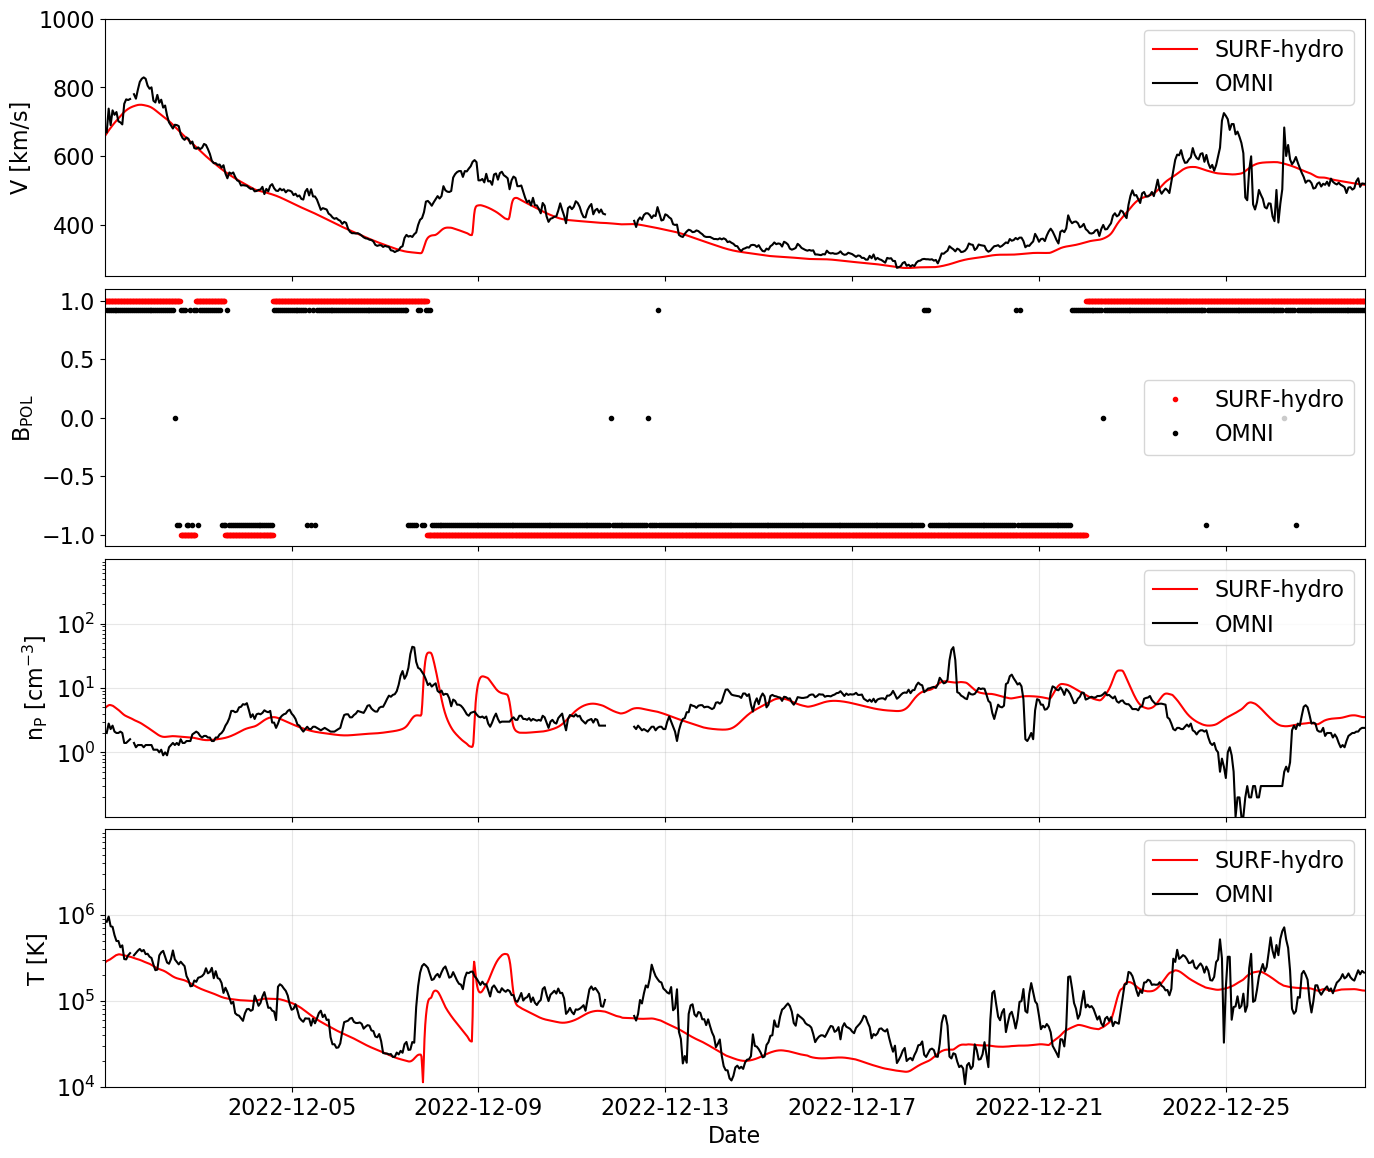

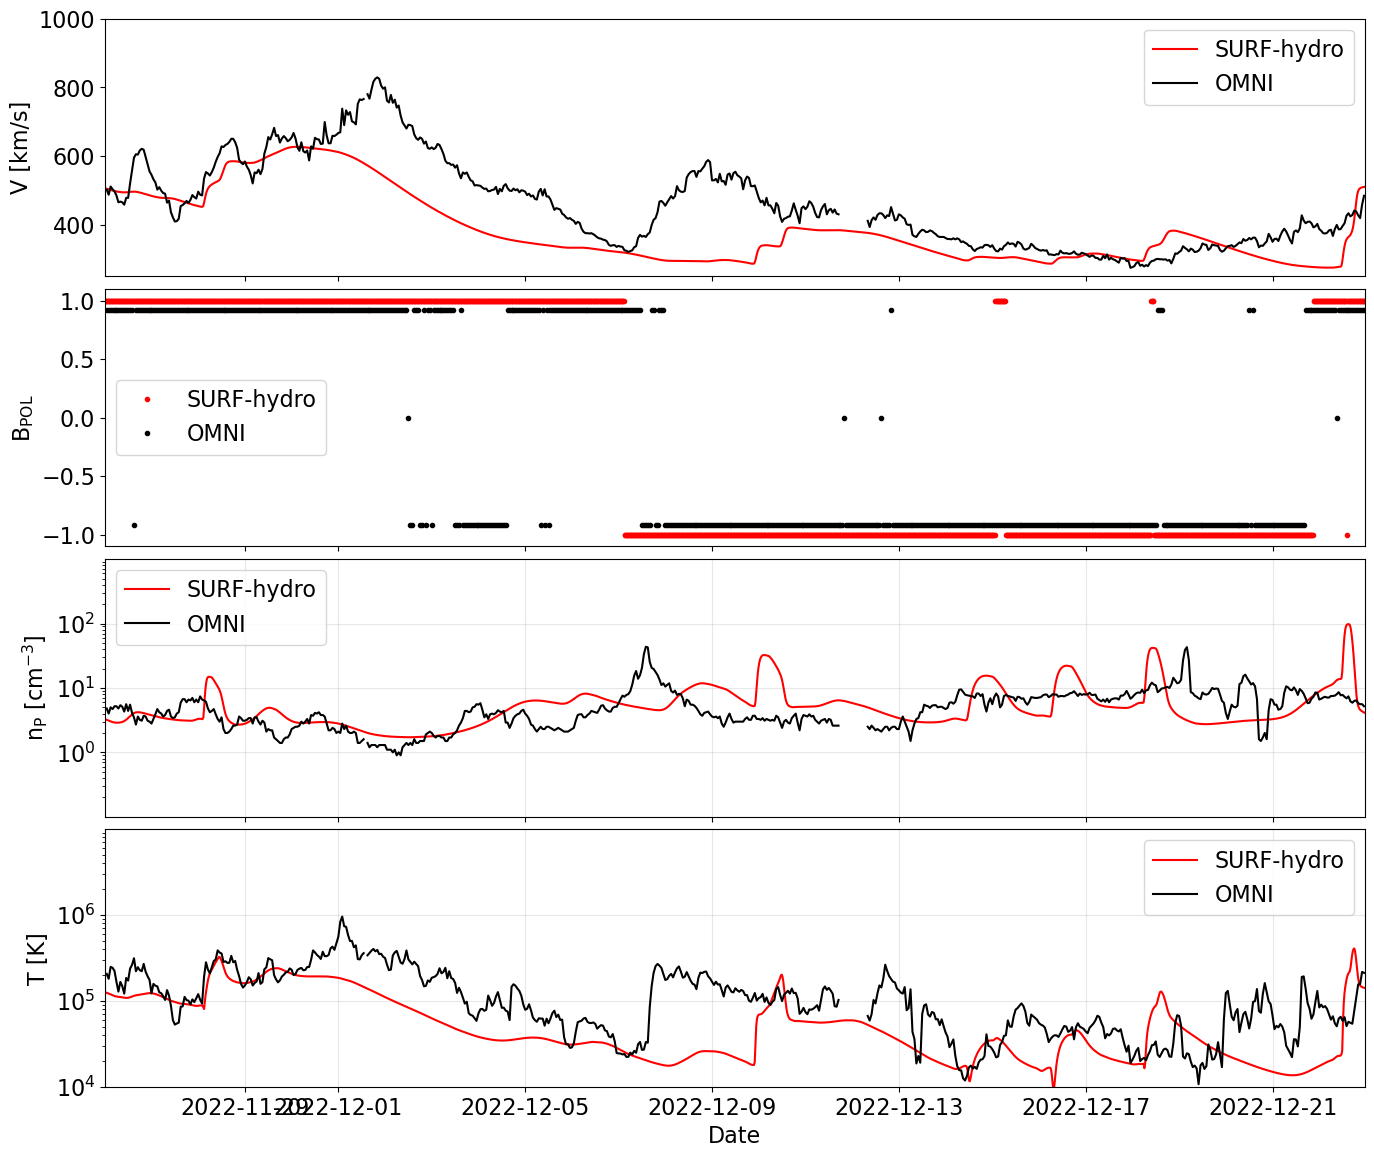

In [2]:
# run compressible SURF in reconstruction mode (i.e. using datao prior to and after the 
#forecast time)

ftime = datetime.datetime(2022,12,1)
cr, cr_lon_init = surfIN.datetime2surfinputs(ftime)
model = surfIS.omniSURF_reconstruction(ftime, ftime +datetime.timedelta(days=27), 
                        rmin=21.5*u.solRad, rmax=250*u.solRad, 
                        dt_scale=4, dt=1*u.day,
                        run_2d=False,
                        solver='hydro',
                        rho_source='speed',
                        temp_source='speed')
model.solve([])
# Plot Earth timeseries
surfA.plot_earth_timeseries(model)


#then run a forecast out to 1 AU
model = surfIS.omniSURF_forecast(ftime, simtime=27*u.day, 
                        rmin=21.5*u.solRad, rmax=250*u.solRad, 
                        dt_scale=4,
                        run_2d=False,
                        solver='hydro',
                        rho_source='speed',
                        temp_source='speed')

model.solve([])
# Plot Earth timeseries
surfA.plot_earth_timeseries(model)
